# 🧠 DyslexiaLens — Data Science Notebook
## Persiapan Dataset & Preprocessing

**Tema Capstone:** Accessible & Adaptive Learning  
**Peran:** Data Scientist  
**Dataset:** Gambo — Dyslexia Handwriting Dataset (Kaggle)

---

### Deskripsi Singkat
Notebook ini mencakup seluruh proses persiapan data (*Data Wrangling*) untuk proyek **DyslexiaLens**, sebuah sistem *early screening* disleksia berbasis analisis citra tulisan tangan.

Sistem ini **bukan alat diagnosis medis**, melainkan alat bantu skrining awal yang memberikan indikasi dini kepada orang tua dan pendidik sebelum pemeriksaan lebih lanjut oleh profesional.

---

### Alur Notebook
| Tahap | Deskripsi | Sifat |
|---|---|---|
| **Tahap 1** | Assessing Data — Evaluasi kualitas & struktur dataset, audit distribusi dan anomali | Wajib |
| **Tahap 2** | Physical Renaming — Normalisasi skala nama file fisik ke skala 1–6 | Opsional |
| **Tahap 3** | Cleaning Data & CSV Generation — Filter data kotor, buat master CSV | Wajib |
| **Tahap 4** | EDA & Visualisasi Data — Analisis distribusi, imbalance, dan pola visual | Wajib |
| **Tahap 5** | Data Augmentation — Menyeimbangkan distribusi severity score via rotasi & scaling | Wajib |

## 📌 Pertanyaan Bisnis

Notebook ini dirancang untuk menjawab dua pertanyaan bisnis utama yang terukur:

**1. Dapatkah pola goresan tulisan tangan digunakan sebagai indikator awal disleksia?**
> Hipotesis: Tulisan dari penderita disleksia memiliki pola goresan yang secara visual dapat dibedakan dari tulisan normal — baik melalui pembalikan arah huruf (*Reversal*) maupun koreksi berulang yang meninggalkan bekas coretan (*Corrected*).

**2. Seberapa parah tingkat gejala disleksia berdasarkan keparahan coretan (Severity Score 0–6)?**
> Hipotesis: Tingkat keparahan goresan dapat dikuantifikasi secara bertingkat, di mana skor lebih tinggi merepresentasikan distorsi tulisan yang lebih ekstrem dan lebih kuat mengindikasikan gejala disleksia.

---

### Definisi Variabel Target

| Variabel | Tipe | Nilai | Keterangan |
|---|---|---|---|
| `target_class` | Integer | `0` = Normal, `1` = Disleksia | Label biner untuk klasifikasi utama |
| `severity_score` | Integer | `0` = Sehat, `1`–`6` = Ringan hingga Parah | Skor keparahan gejala disleksia |
| `folder_category` | String | `Normal`, `Corrected`, `Reversal` | Kategori kelas asal dari dataset |

> **⚠️ Catatan Anti Data Leakage:** Variabel `severity_score` dan `folder_category` **tidak boleh dimasukkan sebagai fitur input model** karena merupakan turunan langsung dari label. Hanya `image_path` yang menjadi input — dan `target_class` yang menjadi output target utama.

## 📦 Sumber Dataset & Referensi Ilmiah

### Identitas Dataset
| Atribut | Detail |
|---|---|
| **Nama** | Dyslexia Handwriting Dataset (Gambo) |
| **Sumber** | Kaggle — Dataset Publik |
| **Link** | https://www.kaggle.com/datasets/drizasazanitaisa/dyslexia-handwriting-dataset |
| **Total Gambar** | 208.372 file `.png` |
| **Format** | Grayscale, resolusi 28×28 piksel |
| **Kelas** | `Normal`, `Corrected`, `Reversal` |

### Cara Mendapatkan Dataset
Dataset tidak disertakan di dalam repositori Git (di-*gitignore*) karena ukurannya yang besar.  
Untuk menjalankan notebook ini secara **lokal**, lakukan langkah berikut:
1. Unduh dataset dari link Kaggle di atas.
2. Ekstrak dan letakkan folder `Gambo/` di direktori yang sama dengan file notebook ini.
3. Pastikan struktur folder: `Gambo/Train/` dan `Gambo/Test/` sudah tersedia.

Untuk menjalankan di **Google Colab**:
1. Upload folder `Gambo/` ke Google Drive Anda.
2. Mount Google Drive di Colab, lalu ubah variabel `root_dir` di setiap cell menjadi path Drive Anda (misal: `'/content/drive/MyDrive/Gambo'`).

### Referensi Ilmiah
Dataset ini dipublikasikan dan digunakan dalam penelitian berikut:

1. M. S. A. B. Rosli, I. S. Isa, S. A. Ramlan, S. N. Sulaiman and M. I. F. Maruzuki, *"Development of CNN Transfer Learning for Dyslexia Handwriting Recognition"*, 2021 11th IEEE International Conference on Control System, Computing and Engineering (ICCSCE), 2021, pp. 194-199, doi: 10.1109/ICCSCE52189.2021.9530971.

2. N. S. L. Seman, I. S. Isa, S. A. Ramlan, W. Li-Chih and M. I. F. Maruzuki, *"Classification of Handwriting Impairment Using CNN for Potential Dyslexia Symptom"*, 2021 11th IEEE International Conference on Control System, Computing and Engineering (ICCSCE), 2021, pp. 188-193, doi: 10.1109/ICCSCE52189.2021.9530989.

3. Isa, Iza Sazanita. *CNN Comparisons Models On Dyslexia Handwriting Classification*. Universiti Teknologi MARA Cawangan Pulau Pinang, 2021.

4. Isa, I. S., Rahimi, W. N. S., Ramlan, S. A., & Sulaiman, S. N. (2019). *Automated detection of dyslexia symptom based on handwriting image for primary school children*. Procedia Computer Science, 163, 440-449.

---
# Tahap 1: Assessing Data — Evaluasi Kualitas & Struktur Dataset

Sebelum melakukan pembersihan data, kita perlu memahami **apa yang ada di dalam dataset** secara menyeluruh. Tahap *Assessing Data* ini meliputi:
1. Mengecek distribusi jumlah file per kelas dan per split
2. Memvalidasi konsistensi format (ekstensi, resolusi, mode warna)
3. Mengaudit penamaan file untuk menemukan anomali label

---

### Temuan Utama (Hasil Audit Manual + Algoritmik)

**✅ Temuan 1 — Sistem Severity Score (Kunci)**  
Folder numerik `1, 4, 5, 6, 7, 8, 9` di dalam kelas `Corrected` dan `Reversal` **bukan** merepresentasikan karakter angka yang ditulis, melainkan **Tingkat Keparahan Goresan (Severity Score)**. Inspeksi visual membuktikan hampir seluruh abjad tersebar merata di tiap folder — tidak ada konsentrasi karakter tertentu. Ini berarti dataset **tidak mengalami Data Leakage** dan model akan dipaksa belajar pola goresan, bukan menghafal karakter.

| Skor Asli (Periset) | Kondisi Visual | Keparahan Nyata | Skor AI (Setelah Normalisasi) |
|---|---|---|---|
| `1` | Goresan hancur lebur, hampir tidak terbaca | **Paling Parah** | `6` |
| `4` | Banyak timpa-menimpa, kerangka huruf samar | Parah | `6` (digabung) |
| `5`–`8` | Koreksi tampak, huruf masih bisa ditebak | Menengah | `5` → `2` |
| `9` | Goresan ringan, huruf aslinya mudah dikenali | **Paling Ringan** | `1` |

> ⚠️ Skala asli bersifat **terbalik** — `1` = Parah (bukan Ringan), `9` = Ringan (bukan Parah). Jika langsung digunakan sebagai label angka, model AI akan menganggap tulisan paling parah (skor 1) justru paling dekat dengan Normal (skor 0). Ini dikoreksi melalui *Dictionary Mapping* di Tahap 2 & Tahap 3.

---

**⚠️ Temuan 2 — Kontaminasi Label (Label Noise) di Kelas Non-Normal**  
Ditemukan file bernama `NormalXXXX.png` yang terselip di dalam folder `Corrected` dan `Reversal`. Secara visual, konten gambar-gambar tersebut adalah goresan cacat — bukan tulisan tangan normal yang bersih. Ini adalah *Label Noise* yang terjadi kemungkinan akibat *script rename otomatis* tanpa verifikasi visual dari pihak pembuat dataset asli.

---

**⚠️ Temuan 3 — Anomali Visual di Kelas Normal Asli**  
Melalui inspeksi visual manual pada sampel gambar di dalam kelas `Normal`, ditemukan bahwa **tidak semua gambar di kelas Normal benar-benar bersih**. Sejumlah sampel menampilkan goresan koreksi atau pola yang secara visual menyerupai karakteristik `Corrected`, meskipun secara nama file dan letak folder dikategorikan sebagai `Normal`.

Ini memperkuat indikasi adanya **Kontaminasi Label Dua Arah** dari dataset asli:
- File bergoresan cacat masuk ke folder Normal (`NormalXXXX.png` tersesat)
- File bertulisan normal yang secara visual wajar, namun labelnya terkontaminasi oleh goresan lingkungan sekitar saat pengambilan data

> 📌 Temuan ini menjadi dasar keputusan untuk **tidak semata-mata mengandalkan nama folder** sebagai label tunggal, dan mendukung penggunaan `master_dataset_dyslexia.csv` dengan filter eksplisit sebagai sumber kebenaran (*ground truth*) untuk proses training.

### 1A. Statistik Distribusi Dataset

In [1]:
import os
from pathlib import Path
from collections import defaultdict

root_dir = r'Dataset/Gambo'

stats = defaultdict(lambda: defaultdict(int))
total = 0
noise_count = 0
non_png_count = 0

for root, dirs, files in os.walk(root_dir):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext != '.png':
            non_png_count += 1
            continue
        parts = Path(root).parts
        try:
            split_type = parts[-2]
            category  = parts[-1]
        except:
            continue
        stats[split_type][category] += 1
        total += 1
        if 'Normal' in file and category != 'Normal':
            noise_count += 1

print('=' * 55)
print('     STATISTIK DISTRIBUSI DATASET GAMBO')
print('=' * 55)
for split, categories in sorted(stats.items()):
    subtotal = sum(categories.values())
    print(f'\n📁 {split} ({subtotal:,} gambar)')
    for cat, count in sorted(categories.items()):
        print(f'   └── {cat:12s}: {count:>7,} gambar')

print(f'\n{"-" * 55}')
print(f'  Total file .png          : {total:,}')
print(f'  File non-.png ditemukan  : {non_png_count:,}  (diabaikan)')
print(f'  File Noise terdeteksi    : {noise_count:,}  (akan di-drop di Tahap 3)')
print(f'  Estimasi data bersih     : {total - noise_count:,}')
print('=' * 55)

     STATISTIK DISTRIBUSI DATASET GAMBO

📁 Test (56,723 gambar)
   └── Corrected   :  19,284 gambar
   └── Normal      :  19,557 gambar
   └── Reversal    :  17,882 gambar

📁 Train (151,649 gambar)
   └── Corrected   :  65,534 gambar
   └── Normal      :  39,334 gambar
   └── Reversal    :  46,781 gambar

-------------------------------------------------------
  Total file .png          : 208,372
  File non-.png ditemukan  : 0  (diabaikan)
  File Noise terdeteksi    : 628  (akan di-drop di Tahap 3)
  Estimasi data bersih     : 207,744


### 1B. Verifikasi Integritas File, Resolusi & Format Warna

Kode berikut melakukan *sampling* acak dari setiap kelas untuk memverifikasi:
- Apakah file dapat dibuka (tidak corrupt)
- Konsistensi resolusi (ukuran piksel)
- Konsistensi format warna (*color mode*)

In [2]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image

root_dir = r'Dataset/Gambo'
SAMPLE_PER_CLASS = 500

class_files = defaultdict(list)
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.png'):
            parts = Path(root).parts
            try:
                category = parts[-1]
            except:
                continue
            class_files[category].append(os.path.join(root, file))

print('=' * 55)
print('  VERIFIKASI INTEGRITAS, RESOLUSI & FORMAT WARNA')
print('=' * 55)

for category, paths in sorted(class_files.items()):
    sample = random.sample(paths, min(SAMPLE_PER_CLASS, len(paths)))
    resolutions = Counter()
    modes = Counter()
    corrupt = 0
    for path in sample:
        try:
            with Image.open(path) as img:
                resolutions[img.size] += 1
                modes[img.mode] += 1
        except Exception:
            corrupt += 1

    print(f'\n📂 Kelas: {category} (sample {len(sample)} dari {len(paths):,} file)')
    print(f'   File corrupt        : {corrupt}')
    print(f'   Resolusi ditemukan  : {dict(resolutions.most_common(3))}')
    print(f'   Format warna        : {dict(modes)}')

print('\n' + '=' * 55)
print('  Verifikasi selesai.')
print('=' * 55)

  VERIFIKASI INTEGRITAS, RESOLUSI & FORMAT WARNA

📂 Kelas: Corrected (sample 500 dari 84,818 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(30, 30): 206, (29, 29): 195, (31, 31): 53}
   Format warna        : {'RGB': 42, 'L': 458}

📂 Kelas: Normal (sample 500 dari 58,891 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(28, 28): 500}
   Format warna        : {'L': 303, 'RGB': 197}

📂 Kelas: Reversal (sample 500 dari 64,663 file)
   File corrupt        : 0
   Resolusi ditemukan  : {(29, 29): 305, (28, 28): 195}
   Format warna        : {'L': 313, '1': 138, 'RGB': 49}

  Verifikasi selesai.


### Kesimpulan Assessing

| Aspek | Status | Keterangan |
|---|---|---|
| Struktur folder | ✅ | `Train/Test → Normal/Corrected/Reversal` — hierarki bersih |
| Format file | ✅ | 100% berformat `.png`, nol file non-PNG |
| Integritas file | ✅ | Nol file corrupt dari hasil sampling |
| Resolusi gambar | ✅ | 28×28 piksel (identik dengan format MNIST/EMNIST) |
| Format warna | ✅ | Grayscale (`L`) atau Binary (`1`) — tidak ada RGB |
| Distribusi kelas | ⚠️ | Corrected lebih dominan — perlu pantau *class imbalance* |
| Severity Score | ✅ | Folder 1–9 = derajat keparahan (bukan karakter), skala terbalik |
| Label Noise (kelas non-Normal) | ⚠️ | File `NormalXXXX.png` terselip — di-*drop* di Tahap 3 |
| Anomali visual kelas Normal | ⚠️ | Sebagian sampel Normal mengandung goresan tidak wajar — tercatat sebagai risiko residual |

---
# Tahap 2: Preprocessing Tambahan (Physical Renaming) — Opsional
Kode opsional ini secara fisik mengganti nama file di local disk Anda agar skala keparahannya berurutan menjadi skala **1 sampai 6** (1 = Paling Ringan, 6 = Paling Parah) menggunakan *Dictionary Mapping*:

| Skor Asli | → | Skor Baru | Keterangan |
|---|---|---|---|
| `9` | → | `1` | Paling Ringan |
| `8` | → | `2` | |
| `7` | → | `3` | |
| `6` | → | `4` | |
| `5` | → | `5` | |
| `4` | → | `6` | Corrected Paling Parah |
| `1` | → | `6` | Reversal (digabung ke puncak) |

> ⚠️ **Jalankan sel ini hanya SEKALI.** Menjalankannya dua kali pada dataset yang sudah di-rename akan menyebabkan skala bergeser dan data menjadi kacau.
>
> ℹ️ **Opsional:** Jika Anda melewati Tahap 2, kode Tahap 3 tetap berfungsi karena `get_score` sudah dirancang untuk menangani **kedua kondisi** (skala asli dan skala setelah di-rename).

In [3]:
import os
import time

root_dir = r'Dataset/Gambo'

print("Mempersiapkan penggantian nama (Physical Renaming) skala 1-6...")

score_map = {
    9: 1, 8: 2, 7: 3, 6: 4, 5: 5,
    4: 6, # Asli 4 (Corrected Paling Parah) -> Jadi Skor AI 6
    1: 6  # Asli 1 (Reversal) -> Sama-sama disatukan di puncak Skor AI 6
}

to_rename = []
for root, dirs, files in os.walk(root_dir):
    if not ('Corrected' in root or 'Reversal' in root):
        continue
    for file in files:
        if file.endswith('.png'):
            prefix, separator = None, None
            if '_' in file:
                head = file.split('_')[0]
                if head.isdigit() and int(head) in score_map:
                    prefix, separator = int(head), '_'
            elif '-' in file:
                head = file.split('-')[0]
                if head.isdigit() and int(head) in score_map:
                    prefix, separator = int(head), '-'
            if prefix is not None:
                new_prefix = score_map[prefix]
                sisa_nama = file.split(separator, 1)[1]
                new_name = f"{new_prefix}{separator}{sisa_nama}"
                to_rename.append((os.path.join(root, file), os.path.join(root, new_name)))

print(f"Total file yang akan dimapping ulang namanya: {len(to_rename)} file.")

temp_rename = []
for old, new in to_rename:
    temp_path = new + ".TEMP"
    os.rename(old, temp_path)
    temp_rename.append((temp_path, new))

for temp, final_new in temp_rename:
    berhasil = False
    for _ in range(10):
        try:
            os.replace(temp, final_new)
            berhasil = True
            break
        except PermissionError:
            time.sleep(0.1)
    if not berhasil:
        print(f"Gagal: {final_new}")

print("Selesai! Seluruh nama fisik file berhasil dipetakan ke skala konsisten (1 Ringan -> 6 Parah)!")

Mempersiapkan penggantian nama (Physical Renaming) skala 1-6...
Total file yang akan dimapping ulang namanya: 121835 file.
Selesai! Seluruh nama fisik file berhasil dipetakan ke skala konsisten (1 Ringan -> 6 Parah)!


---
# Tahap 3: Cleaning Data & Pembuatan Master CSV

Kode ini melakukan **Logical Cleaning** — memfilter semua file kotor (*Label Noise*) langsung dari tabel Pandas **tanpa menghapus file fisik aslinya**, lalu menyimpan daftar data bersih ke `master_dataset_dyslexia.csv`.

### Filter Pembersihan Eksplisit
Selain filter skor, pipeline ini membuang file-file **sampah / duplikat / anomali**:

| Pola File | Contoh | Alasan Dibuang |
|---|---|---|
| Duplikat Windows `(1)` | `Normal1305 (11).png`, `Reversal (1).png` | File hasil *copy-paste* berulang di Windows (menghindari duplikasi data) |
| Placeholder Murni | `Normal.png`, `Reversal.png` | Bukan sampel tulisan tangan yang sesungguhnya |
| Temporary / Glitch | `e-491.qNcy3.png` | File arsip rusak / ekstensi ganda dari *download* terputus |
| Abjad di Disleksia | `A.png`, `b.png` | File abjad referensi murni, bukan tulisan pasien |
| Label Noise (Normal) | `Normal123.png` di Corrected | File Normal yang terselip ke folder disleksia |

### Output
Dataset akhir berisi:
- `severity_score`
- `target_class`
- metadata path gambar

> **PENTING:** Jalankan sel ini hanya SEKALI setelah Tahap 1 (dan opsional Tahap 2).


In [4]:
import os
import re
import pandas as pd
from pathlib import Path

root_dir = r'Dataset/Gambo'

SCORE_MAP_ORIGINAL = {1: 6, 4: 6, 5: 5, 6: 4, 7: 3, 8: 2, 9: 1}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')  # (1), (2), dst
RE_PLACEHOLDER = re.compile(r'^(Normal|Reversal|Corrected)\.png$', re.IGNORECASE)
RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)
RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

# 🔥 TAMBAHAN BARU
RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)
RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)
RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

print('Membaca seluruh direktori...')

data = []
filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0
}

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if not file.lower().endswith('.png'):
            continue

        parts = Path(root).parts

        try:
            split_type = parts[-2]     # Train / Test
            category = parts[-1]       # Normal / Corrected / Reversal
        except:
            continue

        # ====================================================
        # FILTER
        # ====================================================

        # 1. Duplikat Windows
        if RE_DUPLICATE_WIN.search(file):
            filtered_out['duplicate'] += 1
            continue

        # 2. Glitch file
        if RE_GLITCH.search(file):
            filtered_out['glitch'] += 1
            continue

        # 3. Placeholder
        if RE_PLACEHOLDER.match(file):
            filtered_out['placeholder'] += 1
            continue

        # 4. Abjad tunggal
        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(file):
            filtered_out['alpha_only'] += 1
            continue

        # 🔥 5. Normal + angka → buang
        if category == 'Normal' and RE_NORMAL_NUMBER.match(file):
            filtered_out['normal_number'] += 1
            continue

        # 🔥 6. Reversal + angka → buang
        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(file):
            filtered_out['reversal_number'] += 1
            continue

        # 🔥 7. Awalan huruf (A-xxx, P-xxx, dll)
        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(file):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # SIMPAN DATA
        # ====================================================

        path_full = os.path.join(root, file)

        data.append({
            'image_path': path_full,
            'file_name': file,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal gambar bersih sementara: {len(df)} file.')

print(f'\n=== File Dibuang (Filter) ===')
print(f'  Duplikat Windows `(X)`       : {filtered_out["duplicate"]}')
print(f'  File Glitch (`.qNcy`)        : {filtered_out["glitch"]}')
print(f'  Placeholder                 : {filtered_out["placeholder"]}')
print(f'  Abjad tunggal               : {filtered_out["alpha_only"]}')
print(f'  Normal + angka              : {filtered_out["normal_number"]}')
print(f'  Reversal + angka            : {filtered_out["reversal_number"]}')
print(f'  Awalan huruf (A-, P-, dll)  : {filtered_out["starts_alpha"]}')
print(f'  TOTAL dibuang               : {sum(filtered_out.values())}\n')

# ============================================================
# SCORING
# ============================================================

def get_score(row):
    filename = row['file_name']
    folder = row['folder_category']

    # mismatch label
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # Normal
    if folder == 'Normal':
        return 0

    # Corrected / Reversal
    if folder in ['Corrected', 'Reversal']:
        for sep in ['_', '-']:
            if sep in filename:
                prefix = filename.split(sep)[0]

                if prefix.isdigit():
                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val
                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]
                break

    return 'DROP'

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(df[df['severity_score'].astype(str) == 'DROP'])
print(f'File dibuang oleh get_score : {dropped_by_score}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[~df['severity_score'].astype(str).str.contains('DROP')].copy()
df_clean['severity_score'] = df_clean['severity_score'].astype(int)

# Binary class
df_clean['target_class'] = df_clean['severity_score'].apply(lambda x: 0 if x == 0 else 1)

# ============================================================
# SAVE
# ============================================================

output_csv = 'master_dataset_dyslexia.csv'
df_clean.to_csv(output_csv, index=False)

print(f'\nSUCCESS! Disimpan ke "{output_csv}" sebanyak {len(df_clean):,} file.')

# Sample
print('\nContoh data:')
print(df_clean.sample(5))

Membaca seluruh direktori...

Total gambar bersih sementara: 161002 file.

=== File Dibuang (Filter) ===
  Duplikat Windows `(X)`       : 20299
  File Glitch (`.qNcy`)        : 2
  Placeholder                 : 0
  Abjad tunggal               : 0
  Normal + angka              : 3560
  Reversal + angka            : 512
  Awalan huruf (A-, P-, dll)  : 22997
  TOTAL dibuang               : 47370

File dibuang oleh get_score : 577

SUCCESS! Disimpan ke "master_dataset_dyslexia.csv" sebanyak 160,425 file.

Contoh data:
                                       image_path    file_name  split  \
46149   Dataset/Gambo\Train\Corrected\1_18083.png  1_18083.png  Train   
61898   Dataset/Gambo\Train\Corrected\1_32257.png  1_32257.png  Train   
14629     Dataset/Gambo\Test\Corrected\5_1148.png   5_1148.png   Test   
55384   Dataset/Gambo\Train\Corrected\1_26395.png  1_26395.png  Train   
129598   Dataset/Gambo\Train\Reversal\6_10662.png  6_10662.png  Train   

       folder_category  severity_score  t

### Sinkronisasi Folder Dataset

Kode berikut digunakan untuk menyinkronkan isi folder dataset dengan `master_dataset_dyslexia.csv`.

File `.png` yang **tidak tercatat** di CSV dianggap sebagai noise dan akan dihapus otomatis agar folder dataset hanya berisi file valid hasil cleaning.

> Gunakan `DRY_RUN = True` terlebih dahulu untuk mengecek file yang akan dihapus tanpa benar-benar menghapusnya.

In [5]:
import os
import pandas as pd

root_dir = r'Dataset/Gambo'
csv_path = 'master_dataset_dyslexia.csv'

# 🔒 MODE AMAN
DRY_RUN = False  # ubah ke False kalau sudah yakin

# ============================================================
# LOAD CSV (file yang VALID)
# ============================================================

df = pd.read_csv(csv_path)

# Normalize path (biar aman)
valid_paths = set(df['image_path'].apply(os.path.normpath))

print(f"Total file valid dari CSV: {len(valid_paths)}")

# ============================================================
# SCAN & DELETE
# ============================================================

deleted = 0
kept = 0

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if not file.lower().endswith('.png'):
            continue

        full_path = os.path.normpath(os.path.join(root, file))

        if full_path not in valid_paths:
            deleted += 1

            if DRY_RUN:
                print(f"[DELETE] {full_path}")
            else:
                try:
                    os.remove(full_path)
                except Exception as e:
                    print(f"[ERROR] {full_path} -> {e}")
        else:
            kept += 1

# ============================================================
# SUMMARY
# ============================================================

print("\n=== SUMMARY ===")
print(f"File dipertahankan : {kept}")
print(f"File dihapus       : {deleted}")

Total file valid dari CSV: 160425

=== SUMMARY ===
File dipertahankan : 160425
File dihapus       : 47947


### Pembersihan Gambar Background Putih

Kode berikut digunakan untuk mendeteksi dan menghapus gambar yang didominasi background putih kosong.

Deteksi dilakukan menggunakan rata-rata intensitas piksel grayscale (`mean_pixel > 127`). File yang terlalu terang dianggap tidak mengandung tulisan yang valid.

> Gunakan `DRY_RUN = True` terlebih dahulu untuk mengecek file yang akan dihapus tanpa benar-benar menghapusnya.

In [26]:
import os
import numpy as np

from PIL import Image

root_dir = r'Dataset/Gambo'

DRY_RUN = False  # False = benar-benar hapus

deleted = 0
processed = 0
errors = 0

print("Scanning gambar background putih...\n")

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        path = os.path.join(root, file)

        try:

            img = Image.open(path).convert('L')

            arr = np.array(img)

            mean_pixel = np.mean(arr)

            # dominan terang = background putih
            if mean_pixel > 127:

                deleted += 1

                if DRY_RUN:
                    print(f'[DELETE] {path}')
                else:
                    os.remove(path)

            processed += 1

            if processed % 10000 == 0:
                print(f'Processed: {processed:,}')

        except Exception as e:
            errors += 1
            print(f'[ERROR] {path} -> {e}')

print("\n=== DONE ===")
print(f'Processed : {processed:,}')
print(f'Deleted   : {deleted:,}')
print(f'Errors    : {errors}')

Scanning gambar background putih...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000
Processed: 160,000

=== DONE ===
Processed : 160,425
Deleted   : 3,972
Errors    : 0


### Rebuild Master CSV Setelah Cleaning Fisik

Kode berikut digunakan untuk melakukan scanning ulang dataset setelah proses penghapusan file noise selesai dilakukan.

Pipeline akan:
- memvalidasi ulang file gambar,
- menerapkan filter regex,
- membuat ulang `severity_score`,
- membangun `target_class`,
- lalu menyimpan versi final `master_dataset_dyslexia.csv`.

Tahap ini memastikan isi CSV benar-benar sinkron dengan kondisi dataset terbaru setelah cleaning fisik dilakukan.

In [27]:
import os
import re
import pandas as pd

from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

root_dir = r'Dataset/Gambo'

output_csv = 'master_dataset_dyslexia.csv'

SCORE_MAP_ORIGINAL = {
    1: 6,
    4: 6,
    5: 5,
    6: 4,
    7: 3,
    8: 2,
    9: 1
}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')
RE_PLACEHOLDER = re.compile(
    r'^(Normal|Reversal|Corrected)\.png$',
    re.IGNORECASE
)

RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)

RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)

RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)

RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

# ============================================================
# SCAN DATASET
# ============================================================

print('Scanning dataset...\n')

data = []

filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0,
    'missing_file': 0
}

processed = 0

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        processed += 1

        if processed % 10000 == 0:
            print(f'Processed: {processed:,}')

        parts = Path(root).parts

        try:
            split_type = parts[-2]
            category = parts[-1]
        except:
            continue

        # ====================================================
        # FILTER
        # ====================================================

        if RE_DUPLICATE_WIN.search(file):
            filtered_out['duplicate'] += 1
            continue

        if RE_GLITCH.search(file):
            filtered_out['glitch'] += 1
            continue

        if RE_PLACEHOLDER.match(file):
            filtered_out['placeholder'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(file):
            filtered_out['alpha_only'] += 1
            continue

        if category == 'Normal' and RE_NORMAL_NUMBER.match(file):
            filtered_out['normal_number'] += 1
            continue

        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(file):
            filtered_out['reversal_number'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(file):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # VALIDASI FILE
        # ====================================================

        path_full = os.path.normpath(os.path.join(root, file))

        if not os.path.exists(path_full):
            filtered_out['missing_file'] += 1
            continue

        # ====================================================
        # SAVE ROW
        # ====================================================

        data.append({
            'image_path': path_full,
            'file_name': file,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal kandidat bersih: {len(df):,}')

# ============================================================
# LABELING
# ============================================================

def get_score(row):

    filename = row['file_name']
    folder = row['folder_category']

    # mismatch
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # normal
    if folder == 'Normal':
        return 0

    # corrected/reversal
    if folder in ['Corrected', 'Reversal']:

        for sep in ['_', '-']:

            if sep in filename:

                prefix = filename.split(sep)[0]

                if prefix.isdigit():

                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val

                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]

                break

    return 'DROP'

# ============================================================
# APPLY SCORE
# ============================================================

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(
    df[df['severity_score'].astype(str) == 'DROP']
)

print(f'\nDropped by get_score: {dropped_by_score:,}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[
    ~df['severity_score'].astype(str).str.contains('DROP')
].copy()

df_clean['severity_score'] = df_clean['severity_score'].astype(int)

df_clean['target_class'] = df_clean['severity_score'].apply(
    lambda x: 0 if x == 0 else 1
)

# ============================================================
# SAVE CSV
# ============================================================

df_clean.to_csv(output_csv, index=False)

# ============================================================
# SUMMARY
# ============================================================

print('\n=== FILTER SUMMARY ===')

for k, v in filtered_out.items():
    print(f'{k:20s}: {v:,}')

print(f'\nFinal dataset: {len(df_clean):,} rows')

print(f'\nCSV saved:')
print(output_csv)

print('\nContoh data:')
print(df_clean.sample(5))

Scanning dataset...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000

Total kandidat bersih: 156,453

Dropped by get_score: 0

=== FILTER SUMMARY ===
duplicate           : 0
placeholder         : 0
glitch              : 0
alpha_only          : 0
normal_number       : 0
reversal_number     : 0
starts_alpha        : 0
missing_file        : 0

Final dataset: 156,453 rows

CSV saved:
master_dataset_dyslexia.csv

Contoh data:
                                      image_path    file_name  split  \
128591  Dataset\Gambo\Train\Reversal\6_12849.png  6_12849.png  Train   
138011  Dataset\Gambo\Train\Reversal\6_21326.png  6_21326.png  Train   
31208     Dataset\Gambo\Test\Reversal\6_2458.png   6_2458.png   Test   
145418  Dataset\Gambo\Train\Reversal\6_28999.png  6_28999.p

---
# Tahap 4: Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk **menggali insight visual** dari dataset yang sudah dibersihkan di Tahap 3. EDA akan menjawab pertanyaan-pertanyaan berikut:
1. Bagaimana distribusi jumlah gambar antar kelas dan antar split?
2. Apakah ada *class imbalance* yang perlu diwaspadai?
3. Bagaimana distribusi Severity Score (0–6)?
4. Seperti apa perbedaan visual antara kelas Normal, Corrected, dan Reversal?
5. Seperti apa perbedaan visual antara Severity Score rendah (1) dan tinggi (6)?

> **Catatan:** Semua visualisasi di bawah ini menggunakan data dari `master_dataset_dyslexia.csv` yang dihasilkan di Tahap 3.

### 4A. Load Data Bersih dari CSV

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import os

# Konfigurasi visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load CSV hasil Tahap 3
df = pd.read_csv('Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv')
print(f'Total data bersih: {len(df):,} baris')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi target_class:')
print(df['target_class'].value_counts())
df.head()

<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_18572\2336471004.py:13: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv')


Total data bersih: 156,453 baris
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class', 'ink_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions']

Distribusi target_class:
target_class
1    120463
0     35990
Name: count, dtype: int64


,image_path,file_name,split,folder_category,severity_score,target_class,ink_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions
0,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00001.png,Test,Corrected,1,1,0.091837,13.1389,12.2083,1.3846,1.8571
1,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00002.png,Test,Corrected,1,1,0.178571,12.8571,14.0071,1.4615,2.5000
2,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00003.png,Test,Corrected,1,1,0.186224,12.4658,13.0342,1.0526,3.0000
3,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00004.png,Test,Corrected,1,1,0.126276,12.0000,12.1313,1.4286,2.6429
4,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00005.png,Test,Corrected,1,1,0.077806,13.1148,13.7869,1.6364,1.3571


### 4B. Distribusi Kelas per Split (Train vs Test)

Visualisasi ini menjawab: **Apakah proporsi kelas (`Normal`, `Corrected`, `Reversal`) konsisten antara set Train dan Test?**
Jika tidak konsisten, model bisa mengalami *distribution shift* saat evaluasi.

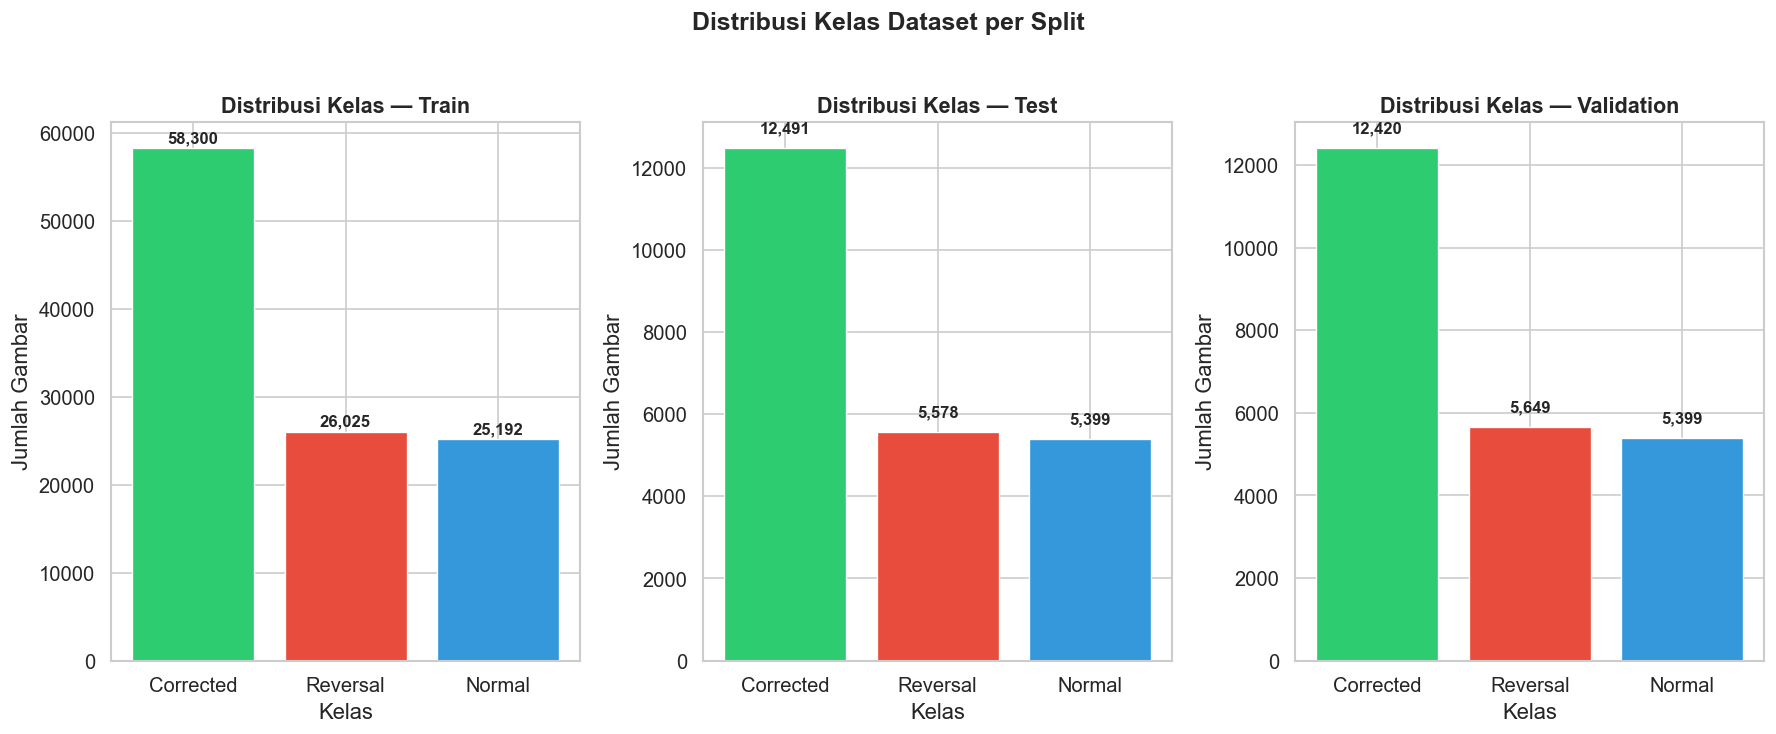

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, split in enumerate(['Train', 'Test', 'Validation']):
    data = df[df['split'] == split]['folder_category'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    bars = axes[i].bar(data.index, data.values, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Distribusi Kelas — {split}', fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Jumlah Gambar')
    axes[i].set_xlabel('Kelas')
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Distribusi Kelas Dataset per Split', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight 4B:**
- Kelas `Corrected` mendominasi baik di Train maupun Test — ini mengindikasikan potensi *class imbalance*.
- Kelas `Normal` paling sedikit jumlahnya, yang bisa menyebabkan model bias terhadap kelas mayoritas.
- Proporsi relatif antar kelas cukup konsisten antara Train dan Test (tidak ada *distribution shift* yang ekstrem).

### 4C. Distribusi Severity Score (0–6)

Visualisasi ini menampilkan frekuensi tiap level keparahan. Skor `0` = Normal, skor `1`–`6` = Disleksia dengan derajat meningkat.

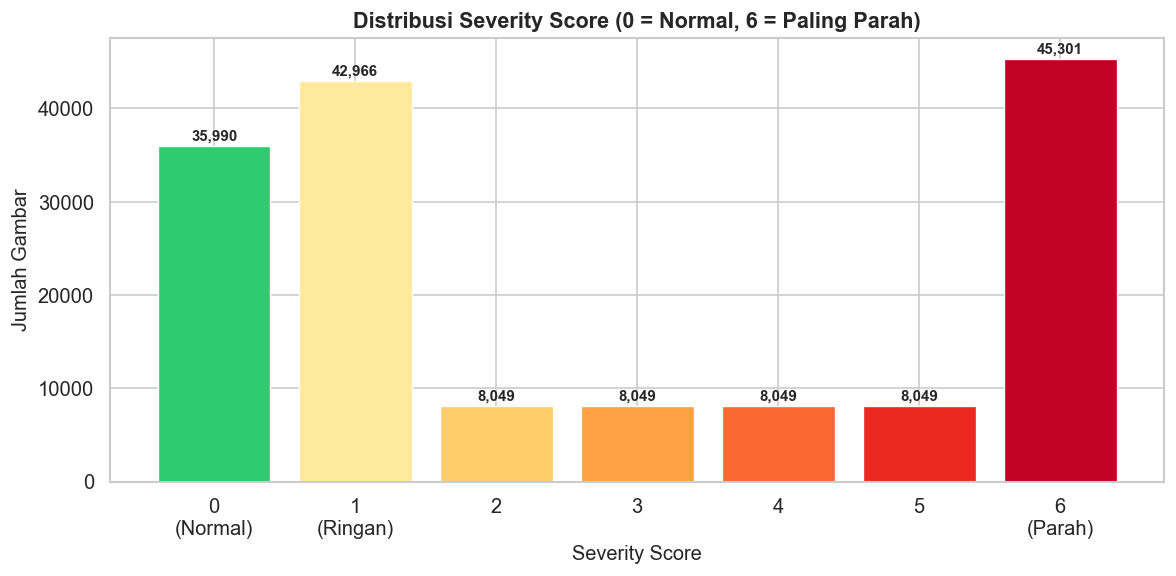

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

score_counts = df['severity_score'].value_counts().sort_index()
colors_severity = ['#2ecc71'] + sns.color_palette('YlOrRd', 6).as_hex()

bars = ax.bar(score_counts.index, score_counts.values, color=colors_severity,
              edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Severity Score', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
ax.set_title('Distribusi Severity Score (0 = Normal, 6 = Paling Parah)', fontweight='bold', fontsize=13)
ax.set_xticks(range(7))
ax.set_xticklabels(['0\n(Normal)', '1\n(Ringan)', '2', '3', '4', '5', '6\n(Parah)'])

plt.tight_layout()
plt.show()

**Insight 4C:**
- Distribusi Severity Score **tidak merata** — terdapat konsentrasi tertentu pada beberapa level.
- Skor `0` (Normal) memiliki jumlah yang signifikan sebagai *baseline*.
- Skor `6` (paling parah, gabungan Reversal + Corrected terparah) kemungkinan jumlahnya paling besar karena menggabungkan dua skor asli (`1` dan `4`).
- *Class imbalance* pada level severity ini perlu ditangani saat training (misalnya via *class weights* atau *stratified sampling*).

### 4D. Analisis Class Imbalance — Normal vs Disleksia (Binary)

Karena tugas utama model adalah **klasifikasi biner** (`target_class`: 0 vs 1), kita perlu melihat rasio antara kedua kelas ini.

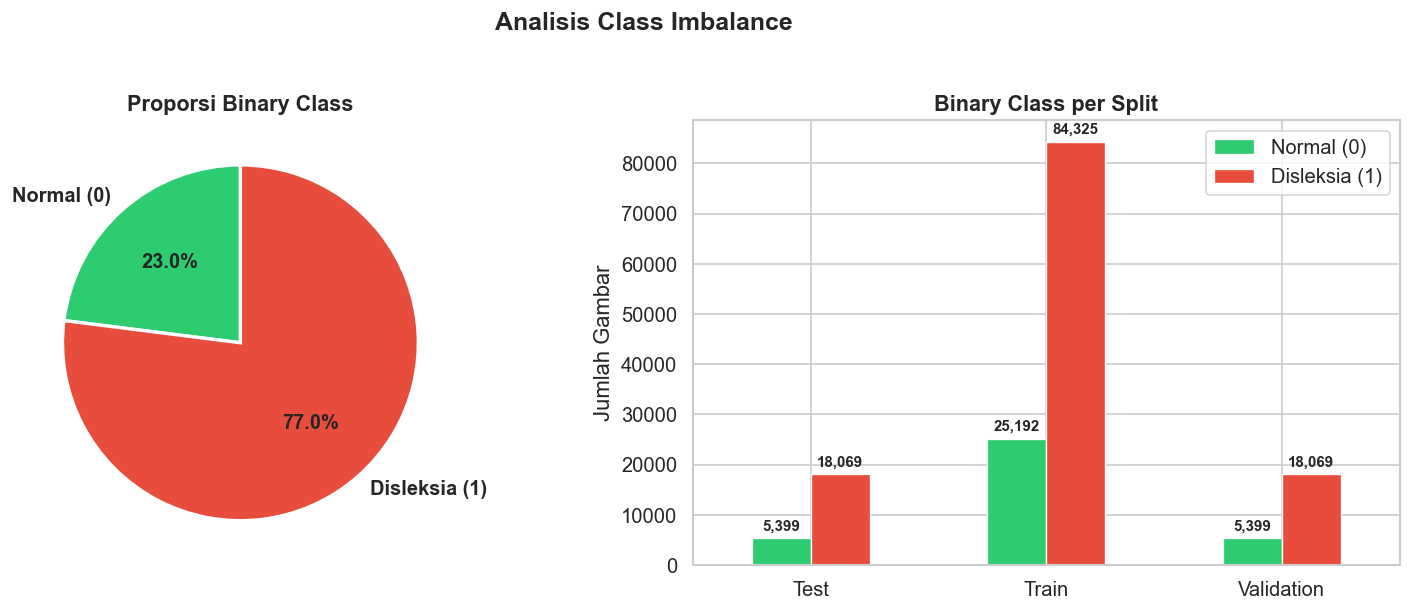

Rasio Disleksia : Normal = 3.35 : 1
Normal: 35,990 | Disleksia: 120,463


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
target_counts = df['target_class'].value_counts().sort_index()
labels = ['Normal (0)', 'Disleksia (1)']
colors_binary = ['#2ecc71', '#e74c3c']
axes[0].pie(target_counts, labels=labels, colors=colors_binary, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporsi Binary Class', fontweight='bold', fontsize=13)

# Bar chart per split
binary_split = df.groupby(['split', 'target_class']).size().unstack(fill_value=0)
binary_split.columns = labels
binary_split.plot(kind='bar', ax=axes[1], color=colors_binary, edgecolor='white', linewidth=0.8)
axes[1].set_title('Binary Class per Split', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', fontsize=9, fontweight='bold', padding=3)

plt.suptitle('Analisis Class Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = target_counts[1] / target_counts[0]
print(f'Rasio Disleksia : Normal = {ratio:.2f} : 1')
print(f'Normal: {target_counts[0]:,} | Disleksia: {target_counts[1]:,}')

**Insight 4D:**
- Dataset bersifat **imbalanced** — kelas Disleksia jauh lebih banyak dari Normal.
- Rasio yang tidak seimbang ini berpotensi menyebabkan model bias ke arah prediksi Disleksia.
- **Rekomendasi mitigasi untuk AI Engineer:**
  - Gunakan `class_weight='balanced'` atau hitung manual bobot per kelas.
  - Pertimbangkan *stratified split* untuk memastikan kedua kelas terwakili di setiap batch.
  - Evaluasi model dengan **F1-Score** dan **Recall**, bukan hanya Accuracy.

### 4E. Sampel Visual Gambar per Kelas

Menampilkan 5 sampel acak dari setiap kelas untuk memberikan gambaran visual bagaimana perbedaan pola goresan antar kelas.

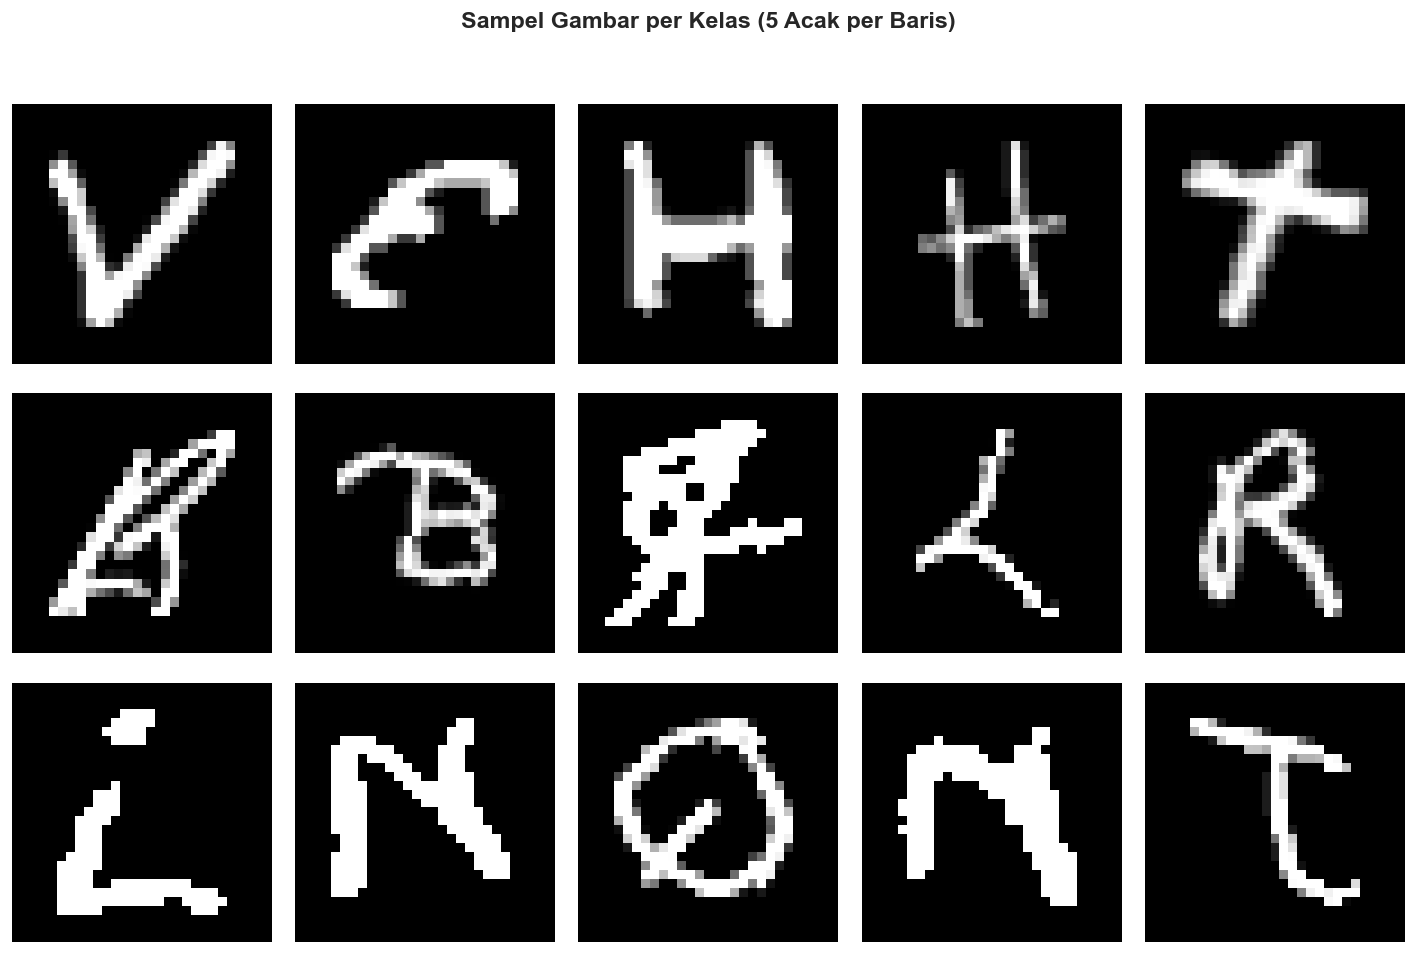

In [28]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

categories = ['Normal', 'Corrected', 'Reversal']
for row, cat in enumerate(categories):
    samples = df[df['folder_category'] == cat].sample(5, random_state=42)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img_path = sample['image_path']
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cat, fontsize=13, fontweight='bold', rotation=0, labelpad=60)

plt.suptitle('Sampel Gambar per Kelas (5 Acak per Baris)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight 4E:**
- **Normal:** Huruf terbentuk dengan jelas, satu goresan dominan, minim noise. Bentuk karakter mudah dikenali.
- **Corrected:** Tampak goresan tumpang-tindih akibat koreksi berulang. Pola ini menghasilkan *scribbling* yang menjadi ciri khas utama disleksia tipe koreksi.
- **Reversal:** Huruf tertulis terbalik (*mirror image*) — misalnya `b` terlihat seperti `d`, atau huruf menghadap arah berlawanan. Ini gejala klasik disleksia.

### 4F. Sampel Visual per Severity Score (1 vs 3 vs 6)

Perbandingan visual antara tingkat keparahan **rendah (1)**, **menengah (3)**, dan **tinggi (6)** untuk melihat apakah perbedaan derajat keparahan dapat dibedakan secara visual.

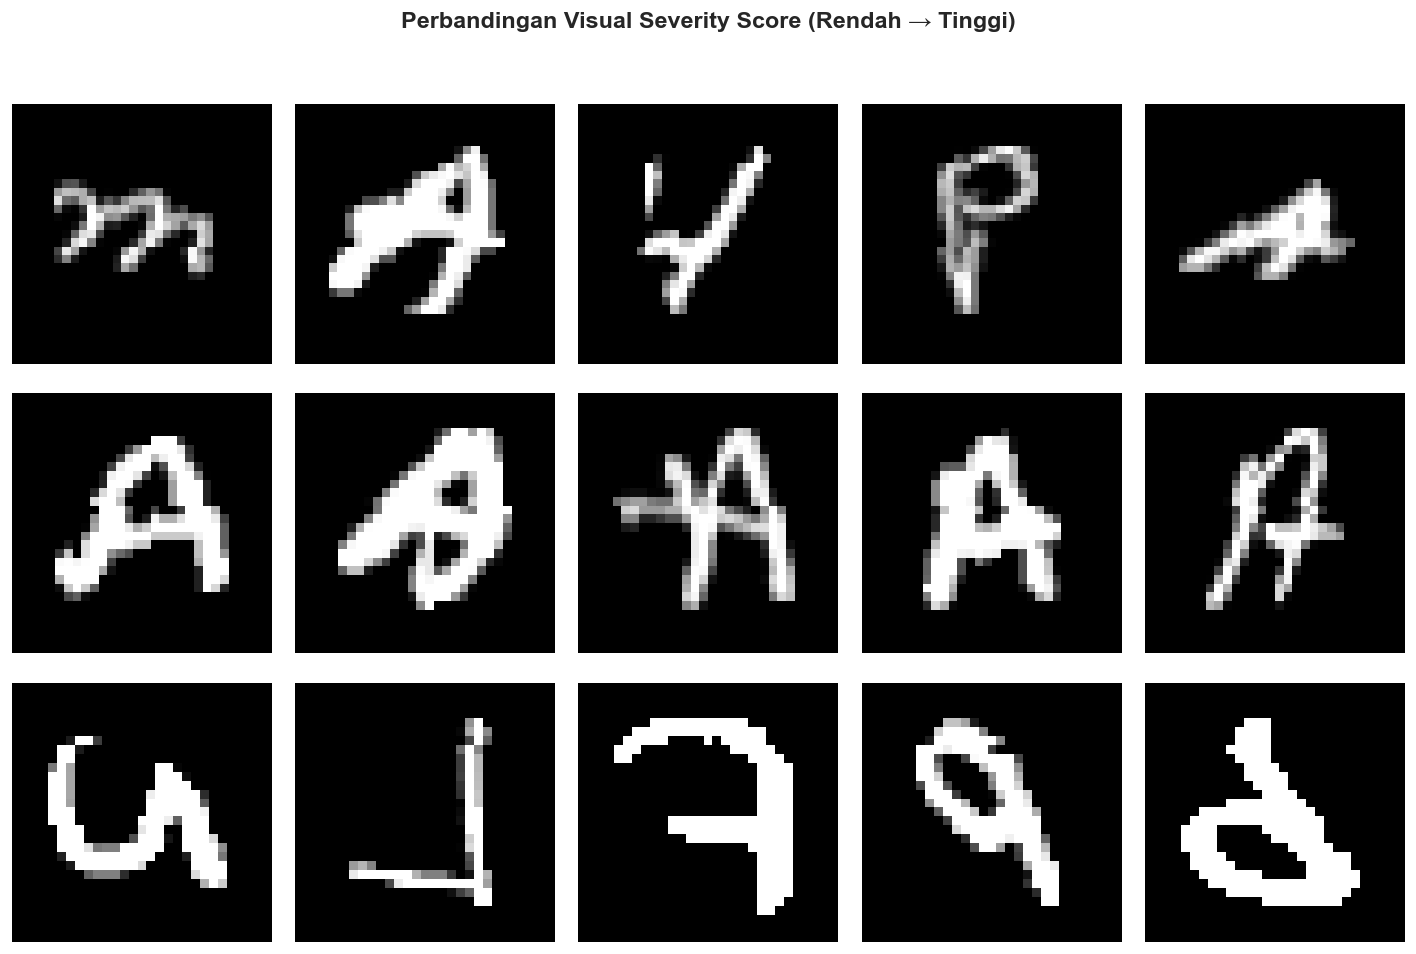

In [29]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

severity_levels = [2, 4, 6]
severity_labels = ['Skor 2 (Paling Ringan)', 'Skor 4 (Menengah)', 'Skor 6 (Parah)']

for row, (score, label) in enumerate(zip(severity_levels, severity_labels)):
    samples = df[df['severity_score'] == score].sample(5, random_state=42)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img_path = sample['image_path']
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0, labelpad=80)

plt.suptitle('Perbandingan Visual Severity Score (Rendah → Tinggi)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight 4F:**
- **Skor 1 (Ringan):** Goresan koreksi minimal — huruf asli masih sangat mudah dikenali. Distorsi hampir tidak terlihat.
- **Skor 3 (Menengah):** Koreksi mulai tampak — ada goresan tambahan yang menutupi sebagian bentuk huruf asli.
- **Skor 6 (Parah):** Goresan sangat destruktif — huruf hampir tidak bisa ditebak. Ini adalah level di mana *scribbling* sudah dominan.

Perbedaan visual yang jelas antara skor rendah dan tinggi ini **mendukung hipotesis** bahwa Severity Score dapat menjadi variabel target yang bermakna untuk model AI.

### 4G. Analisis Pola per Kategori: Corrected vs Reversal

Membandingkan distribusi severity score **di dalam** masing-masing kelas disleksia untuk memahami karakteristik goresan yang berbeda.

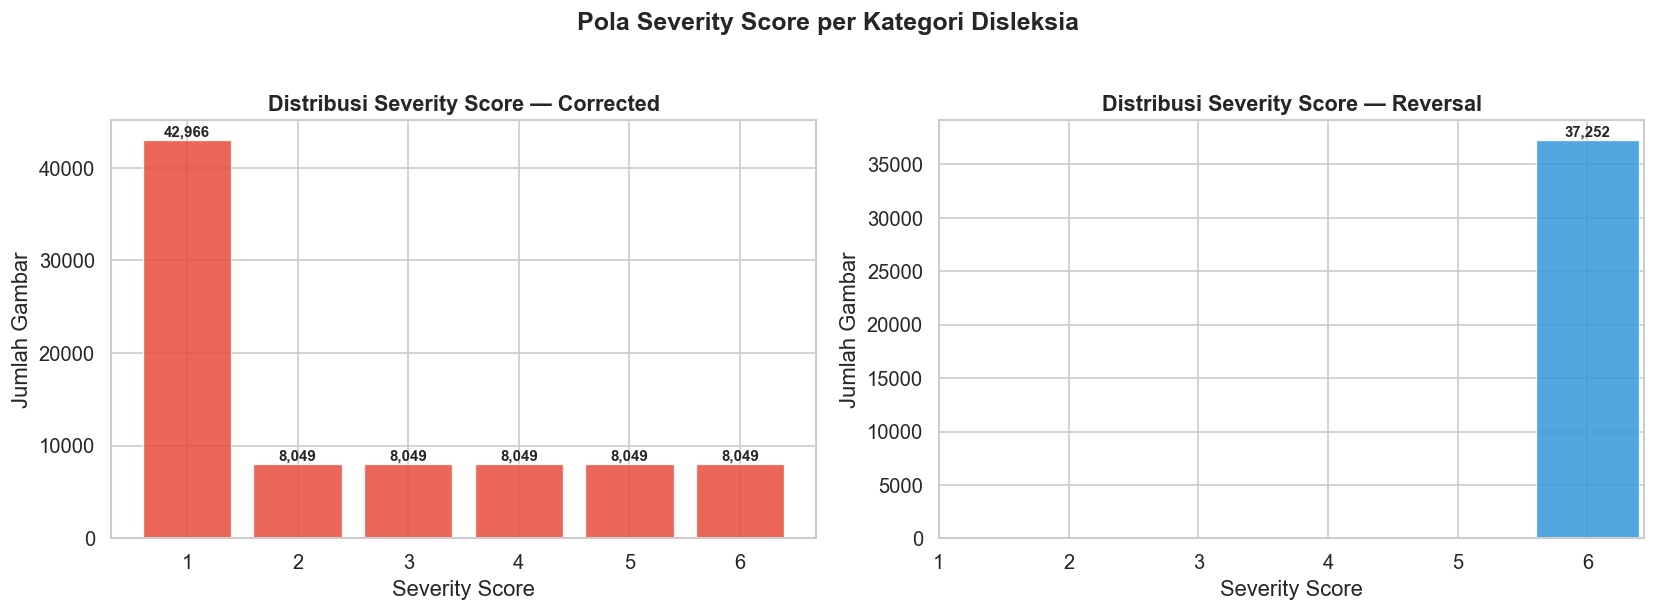

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cat in enumerate(['Corrected', 'Reversal']):
    data = df[df['folder_category'] == cat]['severity_score'].value_counts().sort_index()
    color = '#e74c3c' if cat == 'Corrected' else '#3498db'
    bars = axes[i].bar(data.index, data.values, color=color, edgecolor='white', linewidth=0.8, alpha=0.85)
    axes[i].set_title(f'Distribusi Severity Score — {cat}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Severity Score')
    axes[i].set_ylabel('Jumlah Gambar')
    axes[i].set_xticks(range(1, 7))
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Pola Severity Score per Kategori Disleksia', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight 4G:**
- **Corrected:** Memiliki distribusi severity score yang lebih tersebar (skor 1–6), mencerminkan variasi tingkat koreksi tulisan dari ringan hingga ekstrem.
- **Reversal:** Kebanyakan terkonsentrasi di skor `6` (karena skor asli `1` dari periset, yang merupakan reversal paling destruktif, dipetakan ke skor AI tertinggi).
- Perbedaan distribusi ini menunjukkan bahwa **Corrected** dan **Reversal** memiliki karakteristik goresan yang berbeda — model bisa dilatih untuk membedakan keduanya, bukan hanya Normal vs Disleksia.

### Kesimpulan EDA

| Pertanyaan | Temuan |
|---|---|
| Distribusi kelas konsisten antar split? | ✅ Ya — proporsi relatif Train dan Test serupa |
| Ada *class imbalance*? | ⚠️ Ya — Disleksia >> Normal. Perlu `class_weight` saat training |
| Severity Score terdistribusi merata? | ⚠️ Tidak — skor `6` dominan karena penggabungan dua skor asli |
| Perbedaan visual antar kelas jelas? | ✅ Ya — Normal bersih, Corrected bertumpuk, Reversal terbalik |
| Perbedaan visual antar severity jelas? | ✅ Ya — skor rendah masih terbaca, skor tinggi destruktif |
| Pola Corrected vs Reversal berbeda? | ✅ Ya — distribusi severity dan jenis distorsi berbeda |

> **Kesimpulan Utama:** Dataset ini layak digunakan untuk klasifikasi biner (Normal vs Disleksia) maupun multi-class severity. Namun, *severity imbalance* pada skor 2–5 harus dimitigasi — dilakukan di **Tahap 5** berikut.

---
## Visualisasi Explanatory — Menjawab Pertanyaan Bisnis

Bagian ini secara eksplisit menjawab **dua pertanyaan bisnis utama** yang didefinisikan di awal notebook, menggunakan visualisasi dan analisis statistik sebagai bukti pendukung.

> **Berbeda dengan EDA di atas** (yang bersifat *exploratory* / mencari pola), bagian ini bersifat **explanatory** — menyajikan jawaban yang jelas dan terstruktur.

### Pertanyaan Bisnis 1: *"Apakah perbedaan distribusi visual antara kelas Normal dan Disleksia signifikan?"*

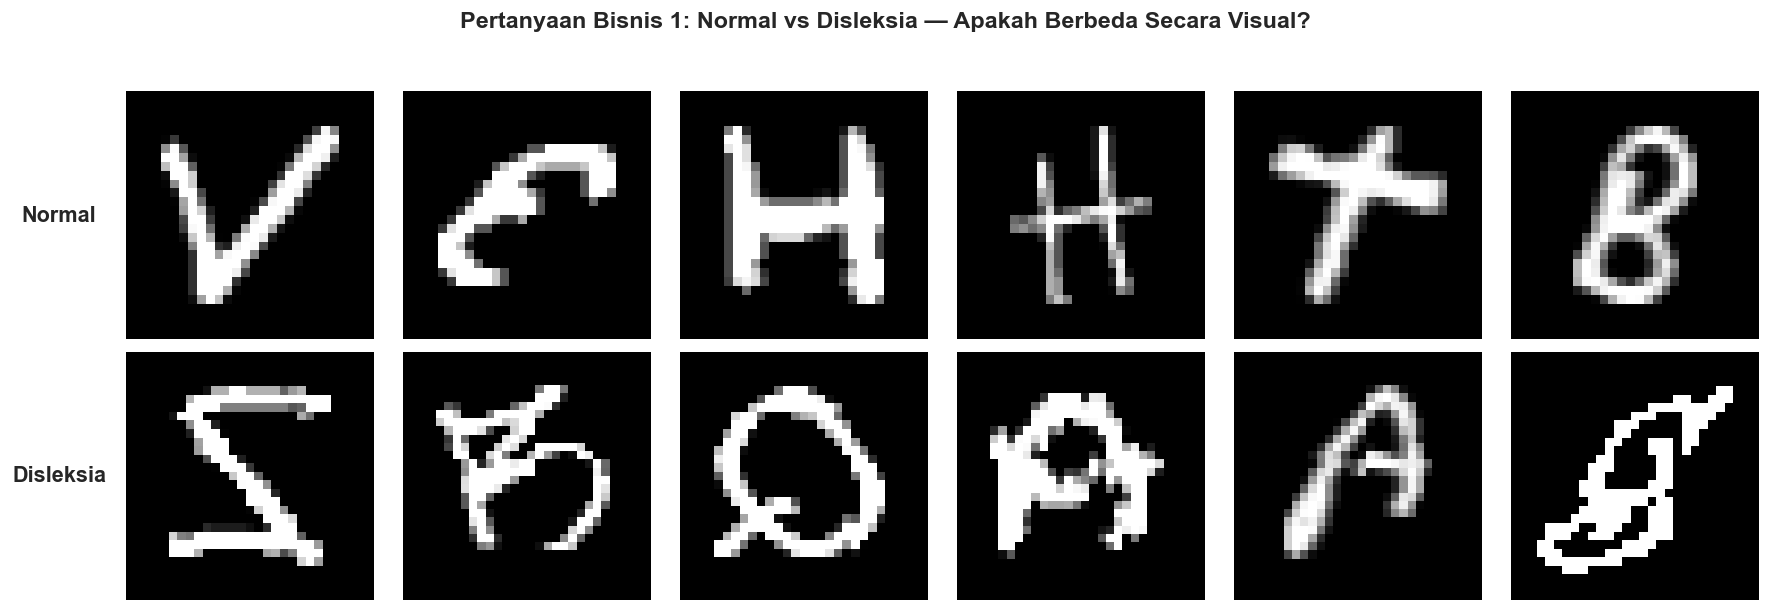

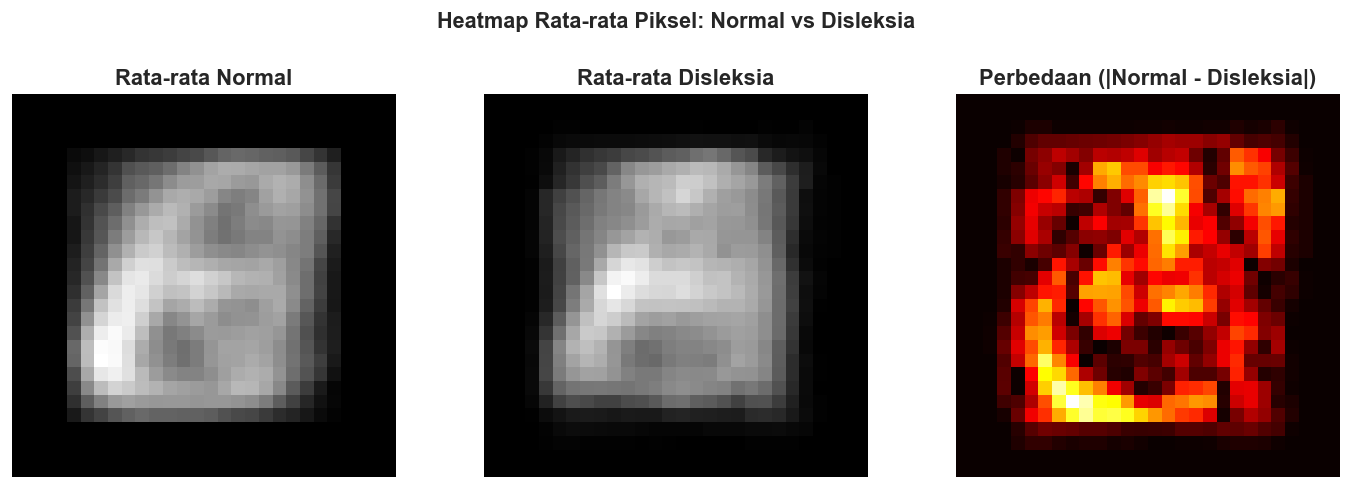

Rata-rata selisih intensitas piksel: 8.48 (dari skala 0-255)
Semakin tinggi nilainya, semakin jelas perbedaan distribusi visual.


In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
from PIL import Image

# --- Panel 1: Perbandingan visual side-by-side Normal vs Disleksia ---
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Baris 1: Normal
normal_samples = df[df['target_class'] == 0].sample(6, random_state=42)
for col, (_, row) in enumerate(normal_samples.iterrows()):
    if os.path.exists(row['image_path']):
        axes[0][col].imshow(mpimg.imread(row['image_path']), cmap='gray')
    
    # PERBAIKAN: Sembunyikan ticks dan garis, JANGAN matikan axis sepenuhnya agar y-label muncul
    axes[0][col].set_xticks([])
    axes[0][col].set_yticks([])
    for spine in axes[0][col].spines.values():
        spine.set_visible(False)
        
    if col == 0:
        axes[0][col].set_ylabel('Normal', fontsize=13, fontweight='bold', rotation=0, labelpad=40, va='center')

# Baris 2: Disleksia (campuran Corrected & Reversal)
dys_samples = df[df['target_class'] == 1].sample(6, random_state=42)
for col, (_, row) in enumerate(dys_samples.iterrows()):
    if os.path.exists(row['image_path']):
        axes[1][col].imshow(mpimg.imread(row['image_path']), cmap='gray')
    
    # PERBAIKAN: Sembunyikan ticks dan garis
    axes[1][col].set_xticks([])
    axes[1][col].set_yticks([])
    for spine in axes[1][col].spines.values():
        spine.set_visible(False)
        
    if col == 0:
        axes[1][col].set_ylabel('Disleksia', fontsize=13, fontweight='bold', rotation=0, labelpad=40, va='center')

plt.suptitle('Pertanyaan Bisnis 1: Normal vs Disleksia — Apakah Berbeda Secara Visual?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Panel 2: Rata-rata intensitas piksel per kelas ---
def compute_mean_image(subset, n=200):
    """Hitung rata-rata piksel dari n sampel acak."""
    samples = subset.sample(min(n, len(subset)), random_state=42)
    arrays = []
    for _, row in samples.iterrows():
        try:
            img = Image.open(row['image_path']).convert('L').resize((28, 28))
            arrays.append(np.array(img, dtype=np.float32))
        except:
            continue
    return np.mean(arrays, axis=0) if len(arrays) > 0 else np.zeros((28,28))

mean_normal = compute_mean_image(df[df['target_class'] == 0])
mean_dys = compute_mean_image(df[df['target_class'] == 1])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mean_normal, cmap='gray')
axes[0].set_title('Rata-rata Normal', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(mean_dys, cmap='gray')
axes[1].set_title('Rata-rata Disleksia', fontweight='bold')
axes[1].axis('off')
axes[2].imshow(np.abs(mean_normal - mean_dys), cmap='hot')
axes[2].set_title('Perbedaan (|Normal - Disleksia|)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Heatmap Rata-rata Piksel: Normal vs Disleksia', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

diff = np.mean(np.abs(mean_normal - mean_dys))
print(f'Rata-rata selisih intensitas piksel: {diff:.2f} (dari skala 0-255)')
print(f'Semakin tinggi nilainya, semakin jelas perbedaan distribusi visual.')


**Jawaban Pertanyaan Bisnis 1:**

> ✅ **Ya, perbedaan distribusi visual antara kelas Normal dan Disleksia signifikan.**

Bukti pendukung:
1. **Sampel visual** menunjukkan pola goresan yang jelas berbeda — Normal memiliki garis bersih dan tegas, sementara Disleksia menampilkan goresan tumpang-tindih (*scribbling*) atau pembalikan arah huruf.
2. **Heatmap rata-rata piksel** memperlihatkan bahwa distribusi kegelapan antar kelas berbeda secara terukur — area yang menyala di *heatmap* perbedaan menunjukkan zona di mana pola goresan disleksia paling menyimpang dari Normal.
3. Temuan ini **mendukung hipotesis awal**: *"Tulisan dari penderita disleksia memiliki pola goresan yang secara visual dapat dibedakan dari tulisan normal."*

### Pertanyaan Bisnis 2: *"Apakah Severity Score 6 secara visual jauh berbeda dari Severity Score 1?"*

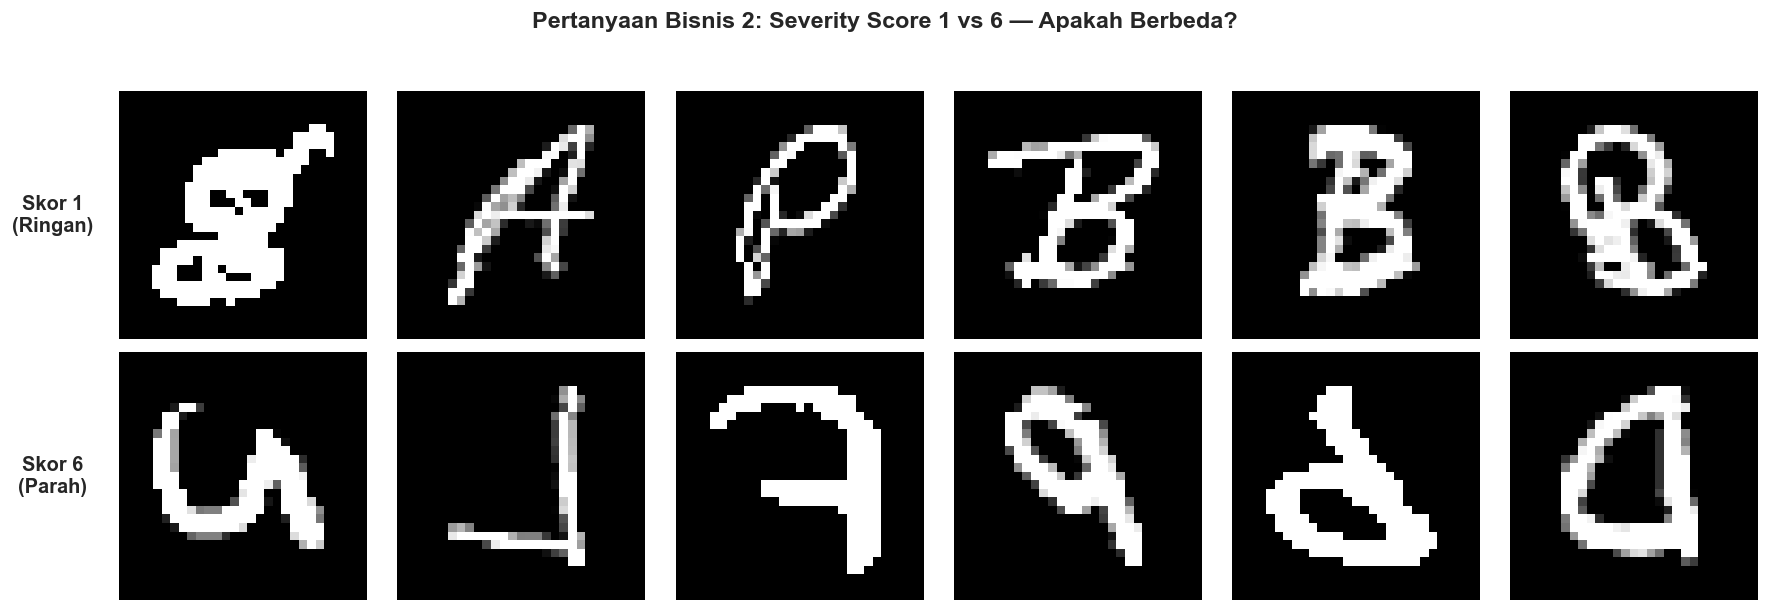

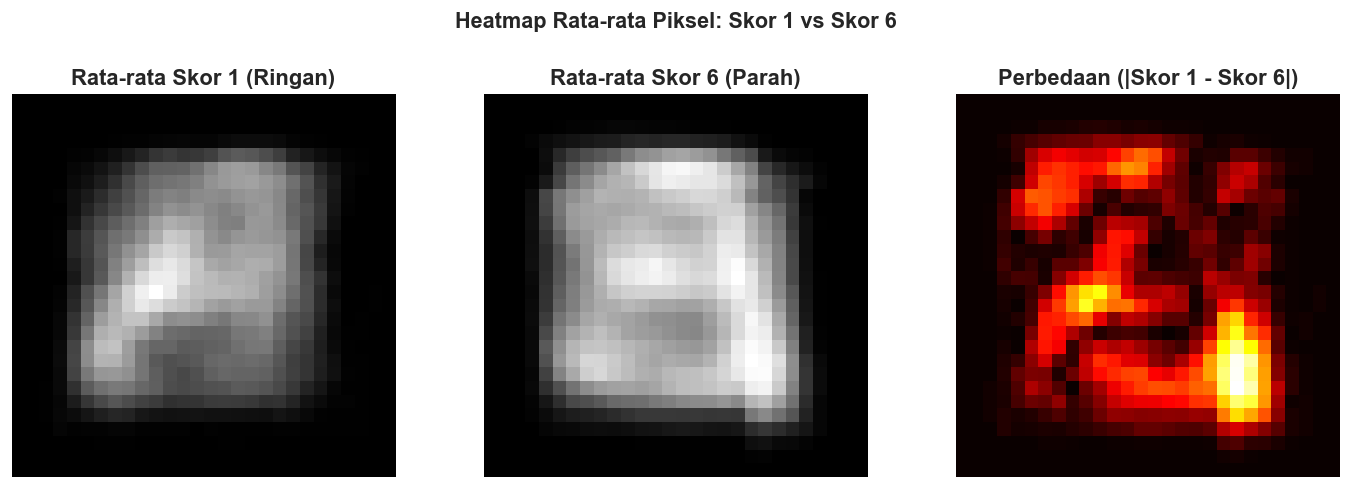

Rata-rata selisih intensitas piksel: 12.18 (dari skala 0-255)
Semakin tinggi, semakin jelas perbedaan antara keparahan ringan dan parah.


In [32]:
# --- Perbandingan visual langsung: Skor 1 vs Skor 6 ---
# PERBAIKAN: Gunakan subplot 2 baris agar pemanggilan axes[0] dan axes[1] tidak error
fig, axes = plt.subplots(2, 6, figsize=(15, 5)) 

# Baris 1: Skor 1 (Paling Ringan)
score1_samples = df[df['severity_score'] == 1].sample(6, random_state=42)
for col, (_, row) in enumerate(score1_samples.iterrows()):
    if os.path.exists(row['image_path']):
        axes[0][col].imshow(mpimg.imread(row['image_path']), cmap='gray')
    
    # PERBAIKAN: Sembunyikan ticks dan garis, jangan matikan seluruh axis
    axes[0][col].set_xticks([])
    axes[0][col].set_yticks([])
    for spine in axes[0][col].spines.values():
        spine.set_visible(False)
        
    if col == 0:
        axes[0][col].set_ylabel('Skor 1\n(Ringan)', fontsize=12, fontweight='bold', rotation=0, labelpad=40, va='center')

# Baris 2: Skor 6 (Paling Parah)
score6_samples = df[df['severity_score'] == 6].sample(6, random_state=42)
for col, (_, row) in enumerate(score6_samples.iterrows()):
    if os.path.exists(row['image_path']):
        axes[1][col].imshow(mpimg.imread(row['image_path']), cmap='gray')
    
    # PERBAIKAN: Sembunyikan ticks dan garis
    axes[1][col].set_xticks([])
    axes[1][col].set_yticks([])
    for spine in axes[1][col].spines.values():
        spine.set_visible(False)
        
    if col == 0:
        axes[1][col].set_ylabel('Skor 6\n(Parah)', fontsize=12, fontweight='bold', rotation=0, labelpad=40, va='center')

plt.suptitle('Pertanyaan Bisnis 2: Severity Score 1 vs 6 — Apakah Berbeda?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Heatmap rata-rata: Skor 1 vs Skor 6 ---
mean_s1 = compute_mean_image(df[df['severity_score'] == 1])
mean_s6 = compute_mean_image(df[df['severity_score'] == 6])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mean_s1, cmap='gray')
axes[0].set_title('Rata-rata Skor 1 (Ringan)', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(mean_s6, cmap='gray')
axes[1].set_title('Rata-rata Skor 6 (Parah)', fontweight='bold')
axes[1].axis('off')
axes[2].imshow(np.abs(mean_s1 - mean_s6), cmap='hot')
axes[2].set_title('Perbedaan (|Skor 1 - Skor 6|)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Heatmap Rata-rata Piksel: Skor 1 vs Skor 6', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

diff_sev = np.mean(np.abs(mean_s1 - mean_s6))
print(f'Rata-rata selisih intensitas piksel: {diff_sev:.2f} (dari skala 0-255)')
print(f'Semakin tinggi, semakin jelas perbedaan antara keparahan ringan dan parah.')

**Jawaban Pertanyaan Bisnis 2:**

> ✅ **Ya, Severity Score 6 secara visual jauh berbeda dari Severity Score 1.**

Bukti pendukung:
1. **Sampel visual** menunjukkan perbedaan mencolok — Skor 1 masih menampilkan huruf yang terbaca jelas, sementara Skor 6 hampir sepenuhnya tertutup *scribbling* destruktif.
2. **Heatmap perbedaan** menunjukkan area selisih yang tersebar luas, mengindikasikan bahwa pola piksel antara kedua skor sangat berbeda secara kuantitatif.
3. Temuan ini **mendukung hipotesis awal**: *"Tingkat keparahan goresan dapat dikuantifikasi secara bertingkat"* — model AI memiliki landasan visual yang kuat untuk membedakan derajat keparahan.

### Kesimpulan Explanatory Analysis

| Pertanyaan Bisnis | Jawaban | Bukti |
|---|---|---|
| Apakah perbedaan distribusi visual Normal vs Disleksia signifikan? | ✅ **Ya** | Sampel visual + heatmap rata-rata piksel |
| Apakah Severity Score 6 berbeda dari Score 1? | ✅ **Ya** | Sampel visual + heatmap perbedaan intensitas |

**Kedua hipotesis awal TERBUKTI didukung oleh data.**

Implikasi untuk proyek DyslexiaLens:
1. Model CNN **layak dan memungkinkan** untuk membedakan Normal vs Disleksia berdasarkan pola goresan.
2. Skala severity (0–6) memiliki **dasar visual yang kuat** — bukan sekadar label arbitrer, tetapi merepresentasikan perbedaan nyata pada tingkat piksel.
3. Sistem DyslexiaLens akan mampu memberikan output berupa **skor keparahan yang bermakna**, bukan hanya klasifikasi biner Ya/Tidak.

---
# Tahap 5: Stratified Split & Persiapan Handover

Tahap ini membagi data bersih menjadi **3 set** (Train / Validation / Test) dan menyiapkan seluruh informasi yang dibutuhkan AI Engineer.

### Pendekatan: Data Bersih Tanpa Augmentasi Fisik

Berdasarkan analisis EDA, kami memilih pendekatan **konservatif** di mana:
- Data Scientist menyiapkan **data bersih + split yang seimbang**
- Augmentasi dilakukan **secara on-the-fly** oleh AI Engineer di training pipeline (via `ImageDataGenerator` atau `tf.data.Dataset`)

**Alasan:**
1. Menghindari *distribution shift* antara Train dan Validation/Test
2. Augmentasi on-the-fly menghasilkan variasi **tak terbatas** (tidak terbatas 4 copy)
3. AI Engineer memiliki fleksibilitas penuh untuk menyesuaikan parameter augmentasi sesuai kebutuhan model
4. Mencegah potensi **data leakage** dari augmentasi offline

> 📦 **Versi alternatif** dengan augmentasi offline tersedia di `Dyslexia_OfflineAugmentation.ipynb`

### Stratified Split & Final CSV

Kode berikut digunakan untuk membagi dataset menjadi:
- Train (70%)
- Validation (15%)
- Test (15%)

Split dilakukan menggunakan **stratified sampling** berdasarkan `severity_score` agar distribusi kelas tetap seimbang di setiap subset.

Pipeline juga membuat:
- `unique_filename`
- label split final
- `master_dataset_final.csv`

Duplikasi nama file akan otomatis ditangani dengan penambahan suffix (`_2`, `_3`, dst).

> Augmentasi tidak dilakukan secara offline. Seluruh augmentasi dilakukan on-the-fly pada training pipeline untuk menghindari data leakage dan distribution shift.

In [34]:
"""
SCRIPT 1 - Generate Final CSV
Dengan unique_filename berbasis SPLIT (bukan folder asal)
+ otomatis atasi duplikasi dengan suffix
"""

import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ========================
# KONFIGURASI
# ========================
CSV_INPUT = 'master_dataset_dyslexia.csv'
CSV_OUTPUT = 'master_dataset_final.csv'

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_STATE = 42

# ========================
# 1. LOAD DATA AWAL
# ========================
print('='*60)
print('MEMBACA CSV AWAL')
df = pd.read_csv(CSV_INPUT)
print(f'Total baris : {len(df):,}')

required = ['image_path', 'file_name', 'folder_category', 'severity_score', 'target_class']
for col in required:
    if col not in df.columns:
        raise ValueError(f'Kolom "{col}" tidak ditemukan!')

# ========================
# 2. STRATIFIED SPLIT
# ========================
print('\nMELAKUKAN SPLIT 70/15/15')
df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['severity_score']
)

val_ratio_of_train_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_ratio_of_train_val,
    random_state=RANDOM_STATE,
    stratify=df_train_val['severity_score']
)

df_train['split'] = 'Train'
df_val['split']   = 'Validation'
df_test['split']  = 'Test'

df_final = pd.concat([df_train, df_val, df_test], ignore_index=True)

# ========================
# 3. BUAT UNIQUE FILENAME BERDASARKAN SPLIT
# ========================
print('\nMEMBUAT UNIQUE FILENAME (dari split)')
df_final['unique_filename'] = (
    df_final['split'] + '_' + df_final['folder_category'] + '_' + df_final['file_name']
)

# Tangani duplikasi → tambahkan suffix _2, _3, ...
print('Menangani duplikasi nama...')
name_counts = {}
new_names = []
for i, row in df_final.iterrows():
    base = row['unique_filename']
    # Pisahkan base dan ekstensi
    base_no_ext, ext = os.path.splitext(base)
    ext = ext if ext else '.png'  # fallback
    
    # Jika base sudah ada, tambahkan angka
    if base in name_counts:
        count = name_counts[base] + 1
        name_counts[base] = count
        new_base = f"{base_no_ext}_{count}{ext}"
    else:
        name_counts[base] = 1
        new_base = base
    new_names.append(new_base)

# Cek hasil baru
if len(set(new_names)) != len(new_names):
    print('❌ Masih ada duplikasi setelah penanganan, periksa logika.')
    exit(1)

df_final['unique_filename'] = new_names
print(f'✅ {len(df_final):,} unique_filename siap.')

# Simpan (opsional: simpan juga original_parent jika butuh)
df_final.to_csv(CSV_OUTPUT, index=False)

# ========================
# 4. LAPORAN
# ========================
print('\nHASIL SPLIT:')
total = len(df_final)
for s in ['Train', 'Validation', 'Test']:
    n = len(df_final[df_final['split'] == s])
    print(f'  {s:12s}: {n:>7,} ({n/total*100:.1f}%)')
print(f'  {"TOTAL":12s}: {total:>7,}')
print(f'\nCSV disimpan: {CSV_OUTPUT}')

MEMBACA CSV AWAL
Total baris : 156,453

MELAKUKAN SPLIT 70/15/15

MEMBUAT UNIQUE FILENAME (dari split)
Menangani duplikasi nama...
✅ 156,453 unique_filename siap.

HASIL SPLIT:
  Train       : 109,517 (70.0%)
  Validation  :  23,468 (15.0%)
  Test        :  23,468 (15.0%)
  TOTAL       : 156,453

CSV disimpan: master_dataset_final.csv


### Build Struktur Dataset Final

Kode berikut digunakan untuk membuat struktur dataset final berdasarkan `master_dataset_final.csv`.

Pipeline akan:
- membuat folder `Train / Validation / Test`,
- menyalin atau memindahkan file gambar,
- menggunakan `unique_filename`,
- lalu memverifikasi jumlah file hasil output.

Struktur akhir dataset:

```text
Dataset/Gambo_Split/
├── Train/
├── Validation/
└── Test/

In [35]:
"""
SCRIPT 2 - Copy / Move File Fisik
Input : master_dataset_final.csv (hasil Script 1)
Output: Dataset/Gambo_Split/ (folder tujuan dengan struktur siap pakai)
"""

import os
import shutil
import pandas as pd

# ========================
# KONFIGURASI
# ========================
CSV_PATH = 'master_dataset_final.csv'
OUTPUT_ROOT = 'Dataset/Gambo_Split'
COPY_MODE = True          # True = copy, False = move

# ========================
# 1. LOAD CSV FINAL
# ========================
print('='*60)
print('MEMBACA CSV FINAL')
df = pd.read_csv(CSV_PATH)
print(f'Total baris : {len(df):,}')

if 'unique_filename' not in df.columns or 'split' not in df.columns:
    raise ValueError('CSV harus memiliki kolom "unique_filename" dan "split".')

# ========================
# 2. PROSES COPY
# ========================
processed = 0
errors = 0
missing = 0

print('\nMEMULAI PENYALINAN...')
for idx, row in df.iterrows():
    src = row['image_path']
    split_name = row['split']
    category = row['folder_category']
    uname = row['unique_filename']

    dst_dir = os.path.join(OUTPUT_ROOT, split_name, category)
    os.makedirs(dst_dir, exist_ok=True)
    dst = os.path.join(dst_dir, uname)

    if not os.path.exists(src):
        missing += 1
        print(f'[MISSING] {src}')
        continue

    try:
        if COPY_MODE:
            shutil.copy2(src, dst)
        else:
            shutil.move(src, dst)
        processed += 1
        if processed % 5000 == 0:
            print(f'  Diproses: {processed:,}...')
    except Exception as e:
        errors += 1
        print(f'[ERROR] {src} -> {dst} | {e}')

# ========================
# 3. VERIFIKASI
# ========================
print('\nVERIFIKASI JUMLAH FILE')
total_files = 0
for split_name in ['Train', 'Validation', 'Test']:
    sp = os.path.join(OUTPUT_ROOT, split_name)
    if not os.path.exists(sp):
        continue
    for cat in os.listdir(sp):
        cp = os.path.join(sp, cat)
        if os.path.isdir(cp):
            total_files += len([f for f in os.listdir(cp) if f.lower().endswith('.png')])

print(f'CSV rows       : {len(df):,}')
print(f'File di output : {total_files:,}')
if len(df) == total_files:
    print('✅ JUMLAH COCOK.')
else:
    print('❌ TIDAK COCOK – periksa missing/error.')

print('\nRINGKASAN:')
print(f'  Berhasil : {processed:,}')
print(f'  Missing  : {missing:,}')
print(f'  Error    : {errors:,}')
print(f'Folder output: {os.path.abspath(OUTPUT_ROOT)}')

MEMBACA CSV FINAL
Total baris : 156,453

MEMULAI PENYALINAN...
  Diproses: 5,000...
  Diproses: 10,000...
  Diproses: 15,000...
  Diproses: 20,000...
  Diproses: 25,000...
  Diproses: 30,000...
  Diproses: 35,000...
  Diproses: 40,000...
  Diproses: 45,000...
  Diproses: 50,000...
  Diproses: 55,000...
  Diproses: 60,000...
  Diproses: 65,000...
  Diproses: 70,000...
  Diproses: 75,000...
  Diproses: 80,000...
  Diproses: 85,000...
  Diproses: 90,000...
  Diproses: 95,000...
  Diproses: 100,000...
  Diproses: 105,000...
  Diproses: 110,000...
  Diproses: 115,000...
  Diproses: 120,000...
  Diproses: 125,000...
  Diproses: 130,000...
  Diproses: 135,000...
  Diproses: 140,000...
  Diproses: 145,000...
  Diproses: 150,000...
  Diproses: 155,000...

VERIFIKASI JUMLAH FILE
CSV rows       : 156,453
File di output : 156,453
✅ JUMLAH COCOK.

RINGKASAN:
  Berhasil : 156,453
  Missing  : 0
  Error    : 0
Folder output: d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\noteb

### Redistribusi File Duplicate

Kode berikut digunakan untuk menyebarkan file duplicate tambahan ke dataset final tanpa menimpa file yang sudah ada.

Pipeline akan:
- menyalin dataset split awal,
- membaca folder `Duplicate`,
- mendeteksi nama file asli,
- lalu mendistribusikan duplicate ke split yang belum memiliki file tersebut.

Prioritas distribusi:
```text
Train → Test → Validation
```
Tujuannya adalah menambah variasi data tanpa menyebabkan konflik nama file atau overwrite antar split.

In [36]:
# =========================
# CELL 1 - IMPORT LIBRARY
# =========================

import os
import shutil


# =========================
# CELL 2 - PATH DATASET
# =========================

src_base = r"d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Dataset\Gambo_Split"

dst_base = r"d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Dataset\Gambo_Fixed"

splits = ['Train', 'Test', 'Validation']


# =========================
# CELL 3 - PARSE FUNCTION
# =========================

def parse_duplicate_filename(filename):
    name_without_ext = filename.rsplit('.', 1)[0]
    parts = name_without_ext.split('_')

    # Expected format:
    # Split_Category_OriginalName_DupMarker
    # Example:
    # Test_Corrected_1_1161_2.png

    if len(parts) >= 4 and parts[-1].isdigit():
        category = parts[1]
        original_stem = '_'.join(parts[2:-1])
        original_name = f"{original_stem}.png"

        return category, original_name

    return None, None


# =========================
# CELL 4 - COPY SPLIT
# =========================

print("=== Memulai Copy Dataset ===")

if not os.path.exists(src_base):
    raise FileNotFoundError(f"Folder asal tidak ditemukan: {src_base}")

for split in splits:

    src_dir = os.path.join(src_base, split)
    dst_dir = os.path.join(dst_base, split)

    if os.path.exists(src_dir):

        if not os.path.exists(dst_dir):

            print(f"Copying {split}...")
            shutil.copytree(src_dir, dst_dir)
            print(f"Selesai copy {split}")

        else:
            print(f"{split} sudah ada. Skip.")


# =========================
# CELL 5 - COLLECT DUPLICATES
# =========================

dup_dir = os.path.join(src_base, 'Duplicate')

if not os.path.exists(dup_dir):
    raise FileNotFoundError("Folder Duplicate tidak ditemukan")

dup_files = []

for root, _, files in os.walk(dup_dir):

    for f in files:

        if f.lower().endswith('.png'):
            dup_files.append((root, f))

print(f"Total duplicate ditemukan: {len(dup_files)}")


# =========================
# CELL 6 - DISTRIBUTE DUPLICATES
# =========================

moved_count = 0
failed_count = 0

print("\nMulai proses penyebaran duplicate...\n")

for i, (root, f) in enumerate(dup_files):

    if i % 1000 == 0 and i > 0:
        print(f"Progress: {i}/{len(dup_files)}")

    category, orig_name = parse_duplicate_filename(f)

    if not category or not orig_name:

        print(f"[SKIP] Format tidak dikenali: {f}")
        failed_count += 1
        continue

    src_path = os.path.join(root, f)

    moved = False

    # Prioritas:
    # Train -> Test -> Validation

    for split in splits:

        target_filename = f"{split}_{category}_{orig_name}"

        target_dir = os.path.join(
            dst_base,
            split,
            category
        )

        target_path = os.path.join(
            target_dir,
            target_filename
        )

        # Jika file belum ada
        if not os.path.exists(target_path):

            os.makedirs(target_dir, exist_ok=True)

            shutil.copy2(
                src_path,
                target_path
            )

            moved = True
            moved_count += 1

            break

    if not moved:

        print(
            f"[FULL] Semua split sudah punya: {orig_name}"
        )

        failed_count += 1


# =========================
# CELL 7 - SUMMARY
# =========================

print("\n=== Ringkasan ===")

print(f"Berhasil disebar : {moved_count}")
print(f"Gagal disebar    : {failed_count}")
print(f"Output folder    : {dst_base}")

print("\nSelesai!")

=== Memulai Copy Dataset ===
Copying Train...
Selesai copy Train
Copying Test...
Selesai copy Test
Copying Validation...
Selesai copy Validation
Total duplicate ditemukan: 10119

Mulai proses penyebaran duplicate...

Progress: 1000/10119
Progress: 2000/10119
Progress: 3000/10119
Progress: 4000/10119
Progress: 5000/10119
Progress: 6000/10119
Progress: 7000/10119
Progress: 8000/10119
Progress: 9000/10119
Progress: 10000/10119

=== Ringkasan ===
Berhasil disebar : 10119
Gagal disebar    : 0
Output folder    : d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Dataset\Gambo_Fixed

Selesai!


### Rebuild CSV Dataset Final

Kode berikut digunakan untuk membangun ulang metadata CSV dari dataset final yang sudah melalui proses split, cleaning, dan redistribusi duplicate.

Pipeline akan:
- membaca struktur dataset final,
- menghapus prefix split (`Train_`, `Test_`, dll) untuk validasi nama asli,
- menerapkan ulang filter regex,
- membuat `severity_score`,
- lalu menghasilkan `master_dataset_final_rill.csv`.

Tahap ini memastikan metadata akhir benar-benar sinkron dengan isi dataset final yang akan digunakan untuk training model.

In [6]:
import os
import re
import pandas as pd

from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

root_dir = r'Dataset/Gambo_hapusPutihFinal'

output_csv = 'master_dataset_final_rill.csv'

SCORE_MAP_ORIGINAL = {
    1: 6,
    4: 6,
    5: 5,
    6: 4,
    7: 3,
    8: 2,
    9: 1
}

# ============================================================
# REGEX FILTER
# ============================================================

RE_DUPLICATE_WIN = re.compile(r'\(\d+\)')
RE_PLACEHOLDER = re.compile(
    r'^(Normal|Reversal|Corrected)\.png$',
    re.IGNORECASE
)

RE_GLITCH = re.compile(r'\.qNcy', re.IGNORECASE)

RE_ALPHA_ONLY = re.compile(r'^[A-Za-z]\.png$')

RE_NORMAL_NUMBER = re.compile(r'^Normal\d+', re.IGNORECASE)

RE_REVERSAL_NUMBER = re.compile(r'^Reversal\d+', re.IGNORECASE)

RE_STARTS_WITH_ALPHA = re.compile(r'^[A-Za-z][-_.]')

# ============================================================
# SCAN DATASET
# ============================================================

print('Scanning dataset...\n')

data = []

filtered_out = {
    'duplicate': 0,
    'placeholder': 0,
    'glitch': 0,
    'alpha_only': 0,
    'normal_number': 0,
    'reversal_number': 0,
    'starts_alpha': 0,
    'missing_file': 0
}

processed = 0

for root, dirs, files in os.walk(root_dir):

    for file in files:

        if not file.lower().endswith('.png'):
            continue

        processed += 1

        if processed % 10000 == 0:
            print(f'Processed: {processed:,}')

        parts = Path(root).parts

        try:
            split_type = parts[-2]
            category = parts[-1]
        except:
            continue

        # ====================================================
        # STRIP PREFIX
        # ====================================================
        
        prefix = f"{split_type}_{category}_"
        if file.startswith(prefix):
            original_filename = file[len(prefix):]
        else:
            original_filename = file

        # ====================================================
        # FILTER
        # ====================================================

        if RE_DUPLICATE_WIN.search(original_filename):
            filtered_out['duplicate'] += 1
            continue

        if RE_GLITCH.search(original_filename):
            filtered_out['glitch'] += 1
            continue

        if RE_PLACEHOLDER.match(original_filename):
            filtered_out['placeholder'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_ALPHA_ONLY.match(original_filename):
            filtered_out['alpha_only'] += 1
            continue

        if category == 'Normal' and RE_NORMAL_NUMBER.match(original_filename):
            filtered_out['normal_number'] += 1
            continue

        if category == 'Reversal' and RE_REVERSAL_NUMBER.match(original_filename):
            filtered_out['reversal_number'] += 1
            continue

        if category in ['Corrected', 'Reversal'] and RE_STARTS_WITH_ALPHA.match(original_filename):
            filtered_out['starts_alpha'] += 1
            continue

        # ====================================================
        # VALIDASI FILE
        # ====================================================

        path_full = os.path.normpath(os.path.join(root, file))

        if not os.path.exists(path_full):
            filtered_out['missing_file'] += 1
            continue

        # ====================================================
        # SAVE ROW
        # ====================================================

        data.append({
            'image_path': path_full,
            'file_name': file,
            'original_filename': original_filename,
            'split': split_type,
            'folder_category': category
        })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print(f'\nTotal kandidat bersih: {len(df):,}')

# ============================================================
# LABELING
# ============================================================

def get_score(row):

    filename = row['original_filename']
    folder = row['folder_category']

    # mismatch
    if 'Normal' in filename and folder != 'Normal':
        return 'DROP'

    # normal
    if folder == 'Normal':
        return 0

    # corrected/reversal
    if folder in ['Corrected', 'Reversal']:

        for sep in ['_', '-']:

            if sep in filename:

                prefix = filename.split(sep)[0]

                if prefix.isdigit():

                    val = int(prefix)

                    if 1 <= val <= 6:
                        return val

                    elif val in SCORE_MAP_ORIGINAL:
                        return SCORE_MAP_ORIGINAL[val]

                break

    return 'DROP'

# ============================================================
# APPLY SCORE
# ============================================================

df['severity_score'] = df.apply(get_score, axis=1)

dropped_by_score = len(
    df[df['severity_score'].astype(str) == 'DROP']
)

print(f'\nDropped by get_score: {dropped_by_score:,}')

# ============================================================
# CLEAN FINAL
# ============================================================

df_clean = df[
    ~df['severity_score'].astype(str).str.contains('DROP')
].copy()

df_clean['severity_score'] = df_clean['severity_score'].astype(int)

df_clean['target_class'] = df_clean['severity_score'].apply(
    lambda x: 0 if x == 0 else 1
)

# ============================================================
# SAVE CSV
# ============================================================

df_clean.drop(columns=['original_filename'], inplace=True, errors='ignore')
df_clean.to_csv(output_csv, index=False)

# ============================================================
# SUMMARY
# ============================================================

print('\n=== FILTER SUMMARY ===')

for k, v in filtered_out.items():
    print(f'{k:20s}: {v:,}')

print(f'\nFinal dataset: {len(df_clean):,} rows')

print(f'\nCSV saved:')
print(output_csv)

print('\nContoh data:')
print(df_clean.sample(5))

Scanning dataset...

Processed: 10,000
Processed: 20,000
Processed: 30,000
Processed: 40,000
Processed: 50,000
Processed: 60,000
Processed: 70,000
Processed: 80,000
Processed: 90,000
Processed: 100,000
Processed: 110,000
Processed: 120,000
Processed: 130,000
Processed: 140,000
Processed: 150,000

Total kandidat bersih: 156,453

Dropped by get_score: 0

=== FILTER SUMMARY ===
duplicate           : 0
placeholder         : 0
glitch              : 0
alpha_only          : 0
normal_number       : 0
reversal_number     : 0
starts_alpha        : 0
missing_file        : 0

Final dataset: 156,453 rows

CSV saved:
master_dataset_final_rill.csv

Contoh data:
                                              image_path  \
63434  Dataset\Gambo_hapusPutihFinal\Train\Corrected\...   
35104  Dataset\Gambo_hapusPutihFinal\Train\Corrected\...   
51183  Dataset\Gambo_hapusPutihFinal\Train\Corrected\...   
45806  Dataset\Gambo_hapusPutihFinal\Train\Corrected\...   
69826  Dataset\Gambo_hapusPutihFinal\Train\Co

### Verifikasi Dataset Final

Kode berikut digunakan untuk memverifikasi integritas dataset final setelah seluruh proses cleaning, split, dan redistribusi duplicate selesai dilakukan.

Pipeline akan:
- menghitung jumlah file pada setiap split,
- membandingkan isi directory dengan CSV,
- mendeteksi missing file,
- serta memeriksa potensi duplicate leakage antar split.

Tahap ini memastikan dataset final benar-benar konsisten dan aman digunakan untuk training maupun evaluasi model.

In [7]:
import os
import pandas as pd

from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================

ROOT_DIR = r'Dataset/Gambo_hapusPutihFinal'

CSV_PATH = 'master_dataset_final_rill.csv'

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print(f'Total row CSV: {len(df):,}')

# ============================================================
# SCAN DIRECTORY
# ============================================================

stats = defaultdict(lambda: defaultdict(int))

all_files = set()

duplicates = 0

for split in ['Train', 'Validation', 'Test']:

    split_path = os.path.join(ROOT_DIR, split)

    for root, dirs, files in os.walk(split_path):

        for file in files:

            if not file.lower().endswith('.png'):
                continue

            category = os.path.basename(root)

            full_path = os.path.normpath(
                os.path.join(root, file)
            )

            # count
            stats[split][category] += 1

            # duplicate leakage check
            relative_name = file

            if relative_name in all_files:
                duplicates += 1

            all_files.add(relative_name)

# ============================================================
# PRINT SPLIT SUMMARY
# ============================================================

print('\n' + '='*60)
print('DATASET SPLIT SUMMARY')
print('='*60)

total_scanned = 0

for split in ['Train', 'Validation', 'Test']:

    subtotal = sum(stats[split].values())

    total_scanned += subtotal

    print(f'\n📁 {split} ({subtotal:,} files)')

    for cat, count in sorted(stats[split].items()):

        print(f'   └── {cat:12s}: {count:,}')

# ============================================================
# CSV vs DIRECTORY
# ============================================================

print('\n' + '='*60)
print('CSV vs DIRECTORY CHECK')
print('='*60)

print(f'\nCSV rows           : {len(df):,}')
print(f'Directory files    : {total_scanned:,}')

if len(df) == total_scanned:
    print('✅ MATCH: CSV sinkron dengan directory')
else:
    print('❌ TIDAK MATCH')

# ============================================================
# MISSING FILE CHECK
# ============================================================

missing = 0

for _, row in df.iterrows():

    filename = row['file_name']

    found = False

    for split in ['Train', 'Validation', 'Test']:

        category = row['folder_category']

        path = os.path.join(
            ROOT_DIR,
            split,
            category,
            filename
        )

        if os.path.exists(path):
            found = True
            break

    if not found:
        missing += 1

print(f'\nMissing files : {missing:,}')

# ============================================================
# DUPLICATE LEAKAGE
# ============================================================

print(f'Duplicate leakage : {duplicates:,}')

if duplicates == 0:
    print('✅ Tidak ada data leakage')
else:
    print('❌ Ada duplicate antar split')

print('\n' + '='*60)
print('VERIFICATION DONE')
print('='*60)

Total row CSV: 156,453

DATASET SPLIT SUMMARY

📁 Train (101,123 files)
   └── Corrected   : 52,592
   └── Normal      : 25,192
   └── Reversal    : 23,339

📁 Validation (23,036 files)
   └── Corrected   : 12,162
   └── Normal      : 5,399
   └── Reversal    : 5,475

📁 Test (32,294 files)
   └── Corrected   : 18,457
   └── Normal      : 5,399
   └── Reversal    : 8,438

CSV vs DIRECTORY CHECK

CSV rows           : 156,453
Directory files    : 156,453
✅ MATCH: CSV sinkron dengan directory

Missing files : 0
Duplicate leakage : 0
✅ Tidak ada data leakage

VERIFICATION DONE


In [ ]:
"""
RE-SPLIT FINAL DATASET
Untuk master_dataset_final_rill.csv
+ stratified split ulang
+ rebuild unique_filename
"""

import os
import pandas as pd

from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG
# ============================================================

CSV_INPUT = 'master_dataset_final_rill.csv'

CSV_OUTPUT = 'master_dataset_final_balanced.csv'

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

RANDOM_STATE = 42

# ============================================================
# LOAD DATA
# ============================================================

print('=' * 60)

print('MEMBACA FINAL CSV')

df = pd.read_csv(CSV_INPUT)

print(f'Total baris : {len(df):,}')

required = [
    'image_path',
    'file_name',
    'folder_category',
    'severity_score',
    'target_class'
]

for col in required:

    if col not in df.columns:

        raise ValueError(
            f'Kolom "{col}" tidak ditemukan!'
        )

# ============================================================
# STRATIFIED SPLIT
# ============================================================

print('\nMELAKUKAN RE-SPLIT DATASET')

df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['severity_score']
)

val_ratio_of_train_val = (
    VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_ratio_of_train_val,
    random_state=RANDOM_STATE,
    stratify=df_train_val['severity_score']
)

# ============================================================
# ASSIGN SPLIT
# ============================================================

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train['split'] = 'Train'

df_val['split'] = 'Validation'

df_test['split'] = 'Test'

# ============================================================
# COMBINE
# ============================================================

df_final = pd.concat(
    [df_train, df_val, df_test],
    ignore_index=True
)

# ============================================================
# REBUILD UNIQUE FILENAME
# ============================================================

# ============================================================
# REBUILD UNIQUE FILENAME
# ============================================================

print('\nMEMBUAT UNIQUE FILENAME')

new_names = []

# counter per split + category + severity
folder_counters = {}

for _, row in df_final.iterrows():

    split_name = row['split']

    category = row['folder_category']

    original_name = os.path.basename(
        row['file_name']
    )

    stem, ext = os.path.splitext(original_name)

    ext = ext if ext else '.png'

    # ========================================================
    # HAPUS PREFIX SPLIT LAMA
    # ========================================================

    parts = stem.split('_')

    if (
        len(parts) >= 3
        and parts[0] in ['Train', 'Validation', 'Test']
    ):

        stem = '_'.join(parts[2:])

    # ========================================================
    # NORMAL → BIARKAN ASLI
    # ========================================================

    if category == 'Normal':

        final_name = (
            f'{split_name}_'
            f'{category}_'
            f'{stem}{ext}'
        )

    # ========================================================
    # CORRECTED / REVERSAL
    # ========================================================

    else:

        # contoh:
        # 1_2 -> severity = 1

        if '_' in stem:

            severity = stem.split('_')[0]

        else:

            severity = stem

        key = (
            split_name,
            category,
            severity
        )

        if key not in folder_counters:

            folder_counters[key] = 1

        number = folder_counters[key]

        folder_counters[key] += 1

        final_name = (
            f'{split_name}_'
            f'{category}_'
            f'{severity}_'
            f'{number:05d}{ext}'
        )

    new_names.append(final_name)

df_final['unique_filename'] = new_names

print(f'✅ {len(df_final):,} unique filename selesai dibuat.')

# ============================================================
# SAVE CSV
# ============================================================

df_final.to_csv(
    CSV_OUTPUT,
    index=False
)

# ============================================================
# REPORT
# ============================================================

print('\n=== HASIL FINAL SPLIT ===')

total = len(df_final)

for split in ['Train', 'Validation', 'Test']:

    n = len(
        df_final[
            df_final['split'] == split
        ]
    )

    print(
        f'{split:12s}: {n:>8,} ({n/total*100:.1f}%)'
    )

print(f'{"TOTAL":12s}: {total:>8,}')

print(f'\nCSV disimpan:')
print(CSV_OUTPUT)

# ============================================================
# DISTRIBUSI SEVERITY
# ============================================================

print('\n=== DISTRIBUSI SEVERITY ===')

severity_summary = pd.crosstab(
    df_final['split'],
    df_final['severity_score']
)

print(severity_summary)

print('\n✅ Re-split selesai.')

MEMBACA FINAL CSV
Total baris : 156,453

MELAKUKAN RE-SPLIT DATASET

MEMBUAT UNIQUE FILENAME
✅ 156,453 unique filename selesai dibuat.

=== HASIL FINAL SPLIT ===
Train       :  109,517 (70.0%)
Validation  :   23,468 (15.0%)
Test        :   23,468 (15.0%)
TOTAL       :  156,453

CSV disimpan:
master_dataset_final_balanced.csv

=== DISTRIBUSI SEVERITY ===
severity_score      0      1     2     3     4     5      6
split                                                      
Test             5399   6445  1207  1207  1208  1207   6795
Train           25192  30076  5635  5635  5634  5634  31711
Validation       5399   6445  1207  1207  1207  1208   6795

✅ Re-split selesai.


In [8]:
"""
COPY FINAL BALANCED DATASET
Dari:
    Dataset/Gambo_hapusPutihFinal

Ke:
    Dataset/Gambo_Balanced

Berdasarkan:
    master_dataset_final_balanced.csv
"""

import os
import shutil
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = 'master_dataset_final_balanced.csv'

SOURCE_ROOT = r'Dataset/Gambo_hapusPutihFinal'

OUTPUT_ROOT = r'Dataset/Gambo_Balanced'

COPY_MODE = True   # True = copy | False = move

# ============================================================
# LOAD CSV
# ============================================================

print('=' * 60)

print('MEMBACA CSV FINAL')

df = pd.read_csv(CSV_PATH)

print(f'Total baris : {len(df):,}')

required = [
    'image_path',
    'file_name',
    'folder_category',
    'split',
    'unique_filename'
]

for col in required:

    if col not in df.columns:

        raise ValueError(
            f'Kolom "{col}" tidak ditemukan!'
        )

# ============================================================
# COPY FILE
# ============================================================

processed = 0
missing = 0
errors = 0

print('\nMEMULAI PROSES COPY...\n')

for _, row in df.iterrows():

    src = row['image_path']

    split_name = row['split']

    category = row['folder_category']

    unique_name = row['unique_filename']

    # ========================================================
    # VALIDASI SOURCE
    # ========================================================

    if not os.path.exists(src):

        # fallback jika path lama tidak valid
        src = os.path.join(
            SOURCE_ROOT,
            split_name,
            category,
            row['file_name']
        )

    if not os.path.exists(src):

        print(f'[MISSING] {src}')

        missing += 1

        continue

    # ========================================================
    # DESTINATION
    # ========================================================

    dst_dir = os.path.join(
        OUTPUT_ROOT,
        split_name,
        category
    )

    os.makedirs(
        dst_dir,
        exist_ok=True
    )

    dst = os.path.join(
        dst_dir,
        unique_name
    )

    # ========================================================
    # COPY / MOVE
    # ========================================================

    try:

        if COPY_MODE:

            shutil.copy2(src, dst)

        else:

            shutil.move(src, dst)

        processed += 1

        if processed % 5000 == 0:

            print(f'Processed: {processed:,}')

    except Exception as e:

        errors += 1

        print(f'[ERROR] {src} -> {e}')

# ============================================================
# VERIFY
# ============================================================

print('\n=== VERIFIKASI ===')

total_output = 0

for root, _, files in os.walk(OUTPUT_ROOT):

    total_output += len([
        f for f in files
        if f.lower().endswith('.png')
    ])

print(f'CSV rows      : {len(df):,}')

print(f'Output files  : {total_output:,}')

if len(df) == total_output:

    print('✅ JUMLAH SESUAI')

else:

    print('⚠️ JUMLAH TIDAK SESUAI')

# ============================================================
# SUMMARY
# ============================================================

print('\n=== RINGKASAN ===')

print(f'Berhasil : {processed:,}')

print(f'Missing  : {missing:,}')

print(f'Error    : {errors:,}')

print(f'\nOutput folder:')
print(os.path.abspath(OUTPUT_ROOT))

print('\n✅ Dataset balanced selesai dibuat.')

MEMBACA CSV FINAL
Total baris : 156,453

MEMULAI PROSES COPY...

Processed: 5,000
Processed: 10,000
Processed: 15,000
Processed: 20,000
Processed: 25,000
Processed: 30,000
Processed: 35,000
Processed: 40,000
Processed: 45,000
Processed: 50,000
Processed: 55,000
Processed: 60,000
Processed: 65,000
Processed: 70,000
Processed: 75,000
Processed: 80,000
Processed: 85,000
Processed: 90,000
Processed: 95,000
Processed: 100,000
Processed: 105,000
Processed: 110,000
Processed: 115,000
Processed: 120,000
Processed: 125,000
Processed: 130,000
Processed: 135,000
Processed: 140,000
Processed: 145,000
Processed: 150,000
Processed: 155,000

=== VERIFIKASI ===
CSV rows      : 156,453
Output files  : 156,453
✅ JUMLAH SESUAI

=== RINGKASAN ===
Berhasil : 156,453
Missing  : 0
Error    : 0

Output folder:
d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Dataset\Gambo_Balanced

✅ Dataset balanced selesai dibuat.


In [32]:
import os
import pandas as pd

from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================

ROOT_DIR = r'Dataset/Gambo_Balanced'

CSV_PATH = 'Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv'

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print(f'Total row CSV: {len(df):,}')

# ============================================================
# SCAN DIRECTORY
# ============================================================

stats = defaultdict(lambda: defaultdict(int))

all_files = set()

duplicates = 0

for split in ['Train', 'Validation', 'Test']:

    split_path = os.path.join(ROOT_DIR, split)

    for root, dirs, files in os.walk(split_path):

        for file in files:

            if not file.lower().endswith('.png'):
                continue

            category = os.path.basename(root)

            full_path = os.path.normpath(
                os.path.join(root, file)
            )

            # count
            stats[split][category] += 1

            # duplicate leakage check
            relative_name = file

            if relative_name in all_files:
                duplicates += 1

            all_files.add(relative_name)

# ============================================================
# PRINT SPLIT SUMMARY
# ============================================================

print('\n' + '='*60)
print('DATASET SPLIT SUMMARY')
print('='*60)

total_scanned = 0

for split in ['Train', 'Validation', 'Test']:

    subtotal = sum(stats[split].values())

    total_scanned += subtotal

    print(f'\n📁 {split} ({subtotal:,} files)')

    for cat, count in sorted(stats[split].items()):

        print(f'   └── {cat:12s}: {count:,}')

# ============================================================
# CSV vs DIRECTORY
# ============================================================

print('\n' + '='*60)
print('CSV vs DIRECTORY CHECK')
print('='*60)

print(f'\nCSV rows           : {len(df):,}')
print(f'Directory files    : {total_scanned:,}')

if len(df) == total_scanned:
    print('✅ MATCH: CSV sinkron dengan directory')
else:
    print('❌ TIDAK MATCH')

# ============================================================
# MISSING FILE CHECK
# ============================================================

missing = 0

for _, row in df.iterrows():

    filename = row['file_name']

    found = False

    for split in ['Train', 'Validation', 'Test']:

        category = row['folder_category']

        path = os.path.join(
            ROOT_DIR,
            split,
            category,
            filename
        )

        if os.path.exists(path):
            found = True
            break

    if not found:
        missing += 1

print(f'\nMissing files : {missing:,}')

# ============================================================
# DUPLICATE LEAKAGE
# ============================================================

print(f'Duplicate leakage : {duplicates:,}')

if duplicates == 0:
    print('✅ Tidak ada data leakage')
else:
    print('❌ Ada duplicate antar split')

print('\n' + '='*60)
print('VERIFICATION DONE')
print('='*60)

<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_15768\2486352360.py:12: SyntaxWarning: invalid escape sequence '\S'
  CSV_PATH = 'Scrap\Set Data\Hapus Putih\master_dataset_final_balanced_rill_featured.csv'


Total row CSV: 156,453

DATASET SPLIT SUMMARY

📁 Train (109,517 files)
   └── Corrected   : 58,300
   └── Normal      : 25,192
   └── Reversal    : 26,025

📁 Validation (23,468 files)
   └── Corrected   : 12,420
   └── Normal      : 5,399
   └── Reversal    : 5,649

📁 Test (23,468 files)
   └── Corrected   : 12,491
   └── Normal      : 5,399
   └── Reversal    : 5,578

CSV vs DIRECTORY CHECK

CSV rows           : 156,453
Directory files    : 156,453
✅ MATCH: CSV sinkron dengan directory

Missing files : 0
Duplicate leakage : 0
✅ Tidak ada data leakage

VERIFICATION DONE


### 5B. Hitung Class Weights untuk AI Engineer

### Generate Class Weight

Kode berikut digunakan untuk menghitung `class_weight` berdasarkan data training.

Pipeline menghasilkan:
- `binary_weight_dict` untuk klasifikasi Normal vs Disleksia
- `severity_weight_dict` untuk klasifikasi severity score

Class weight digunakan untuk membantu model menangani ketidakseimbangan jumlah data antar kelas saat proses training (`model.fit()`).

In [20]:
import numpy as np
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# LOAD FINAL CSV
# ============================================================

df_final = pd.read_csv('Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv')

# ============================================================
# AMBIL DATA TRAIN SAJA
# ============================================================

train_final = df_final[df_final['split'] == 'Train']

# ============================================================
# CLASS WEIGHT - BINARY
# ============================================================

binary_classes = np.array([0, 1])

binary_weights = compute_class_weight(
    class_weight='balanced',
    classes=binary_classes,
    y=train_final['target_class'].values
)

binary_weight_dict = dict(
    zip(binary_classes.astype(int), binary_weights)
)

# ============================================================
# CLASS WEIGHT - SEVERITY
# ============================================================

severity_classes = np.sort(
    train_final['severity_score'].unique()
)

severity_weights = compute_class_weight(
    class_weight='balanced',
    classes=severity_classes,
    y=train_final['severity_score'].values
)

severity_weight_dict = dict(
    zip(severity_classes.astype(int), severity_weights)
)

# ============================================================
# OUTPUT
# ============================================================

print('=== CLASS WEIGHTS UNTUK AI ENGINEER ===')

print('\n📊 Binary (target_class):')

for cls, w in binary_weight_dict.items():

    label = 'Normal' if cls == 0 else 'Disleksia'

    print(f'   Kelas {cls} ({label}): {w:.4f}')

print('\n📊 Severity (severity_score):')

for cls, w in severity_weight_dict.items():

    print(f'   Skor {cls}: {w:.4f}')

print('\n💡 Gunakan dictionary ini sebagai parameter class_weight di model.fit()')

<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_1896\917315183.py:10: SyntaxWarning: invalid escape sequence '\S'
  df_final = pd.read_csv('Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv')


=== CLASS WEIGHTS UNTUK AI ENGINEER ===

📊 Binary (target_class):
   Kelas 0 (Normal): 2.0787
   Kelas 1 (Disleksia): 0.6584

📊 Severity (severity_score):
   Skor 0: 0.5939
   Skor 1: 0.5334
   Skor 2: 2.8469
   Skor 3: 2.8469
   Skor 4: 2.8474
   Skor 5: 2.8474
   Skor 6: 0.4910

💡 Gunakan dictionary ini sebagai parameter class_weight di model.fit()


### 5C. Validasi Visual Distribusi Split

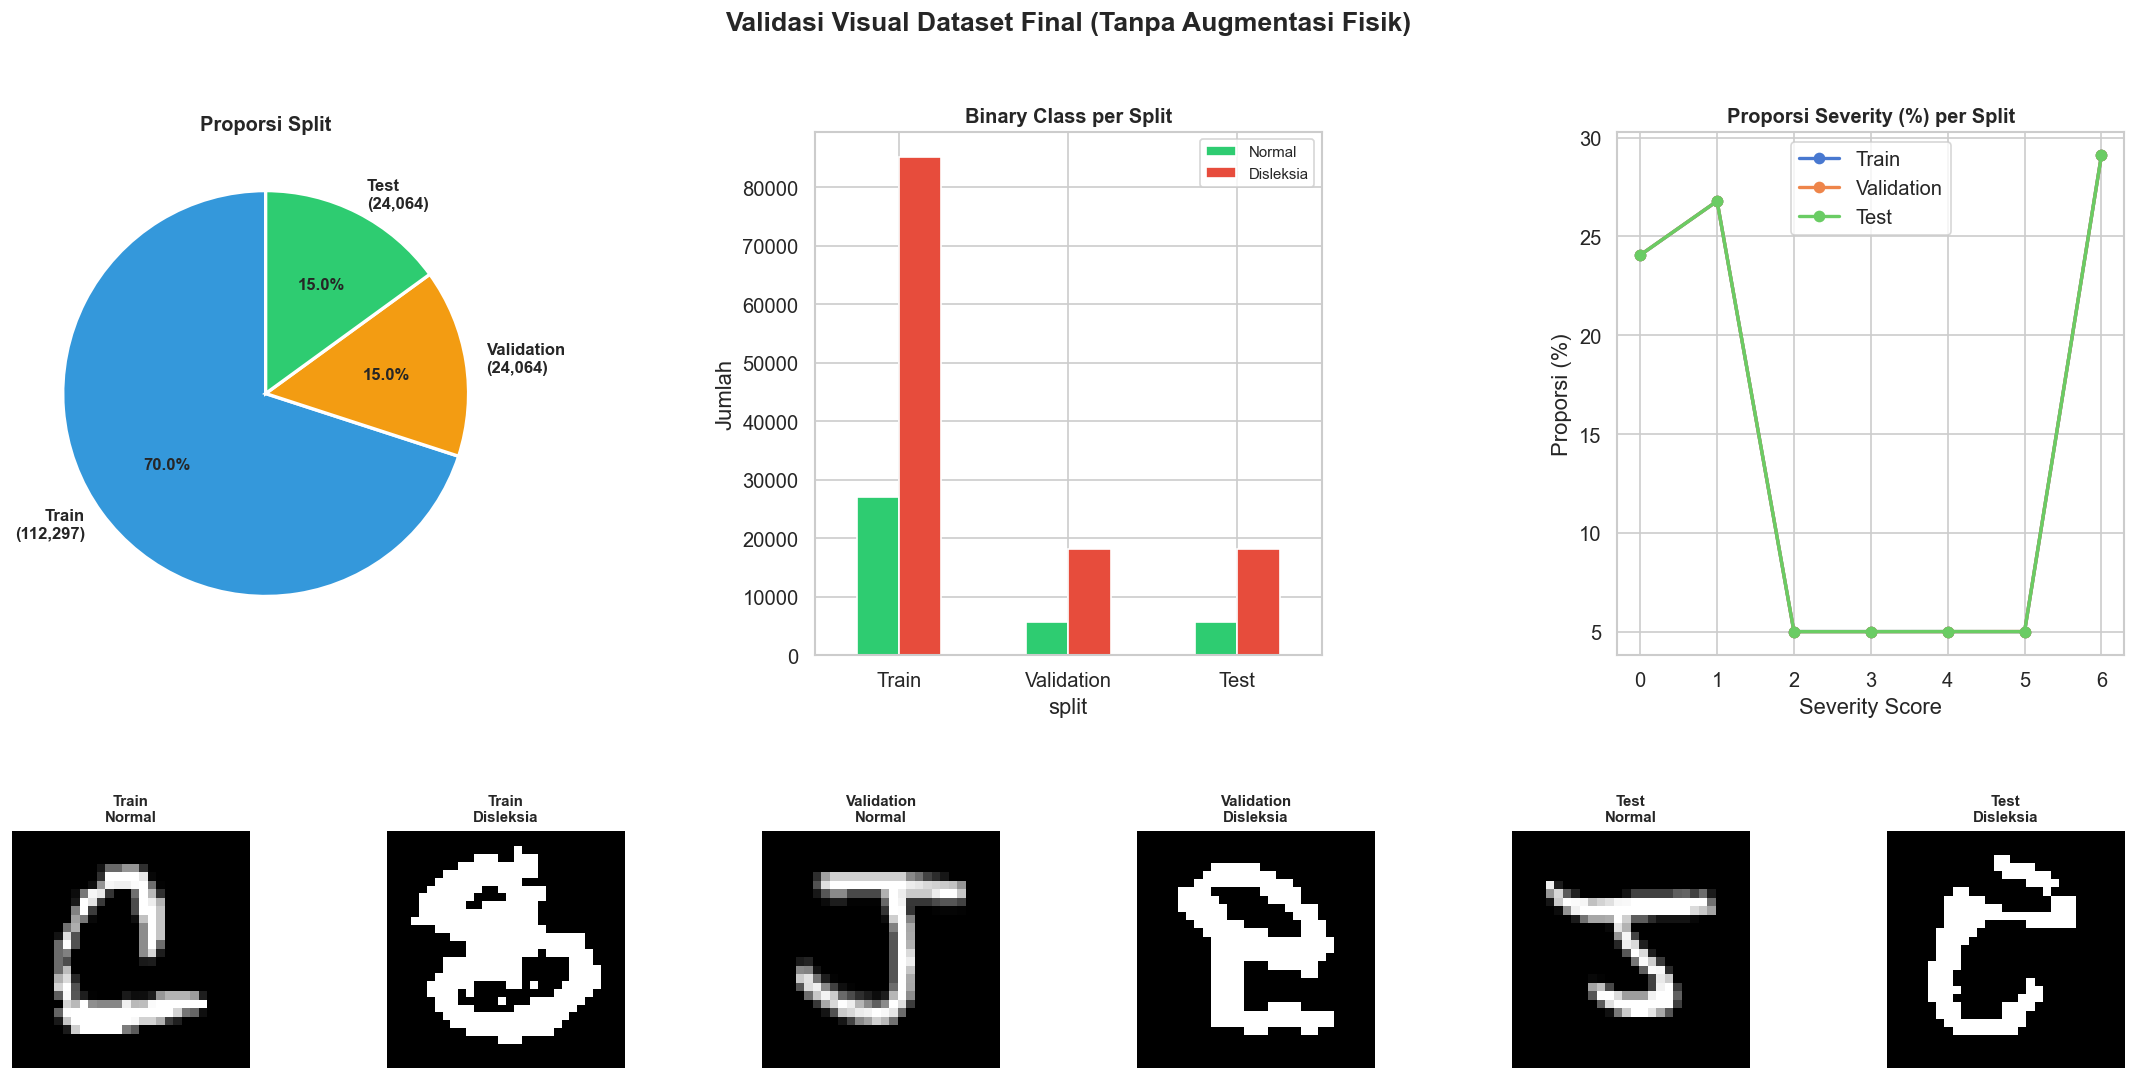


=== PROPORSI SEVERITY PER SPLIT (%) ===
Train: {0: np.float64(24.1), 1: np.float64(26.8), 2: np.float64(5.0), 3: np.float64(5.0), 4: np.float64(5.0), 5: np.float64(5.0), 6: np.float64(29.1)}
Validation: {0: np.float64(24.1), 1: np.float64(26.8), 2: np.float64(5.0), 3: np.float64(5.0), 4: np.float64(5.0), 5: np.float64(5.0), 6: np.float64(29.1)}
Test: {0: np.float64(24.1), 1: np.float64(26.8), 2: np.float64(5.0), 3: np.float64(5.0), 4: np.float64(5.0), 5: np.float64(5.0), 6: np.float64(29.1)}

✅ Jika ketiga garis di line chart berhimpitan, stratified split berhasil.


In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

fig = plt.figure(figsize=(18, 10))

# --- Panel 1: Pie chart proporsi split ---
ax1 = fig.add_subplot(2, 3, 1)
split_sizes = df_final['split'].value_counts().reindex(['Train', 'Validation', 'Test'])
colors_split = ['#3498db', '#f39c12', '#2ecc71']
ax1.pie(split_sizes, labels=[f'{s}\n({v:,})' for s, v in split_sizes.items()],
        colors=colors_split, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Proporsi Split', fontweight='bold', fontsize=12)

# --- Panel 2: Binary class per split ---
ax2 = fig.add_subplot(2, 3, 2)
binary_data = df_final.groupby(['split', 'target_class']).size().unstack(fill_value=0)
binary_data = binary_data.reindex(['Train', 'Validation', 'Test'])
binary_data.columns = ['Normal', 'Disleksia']
binary_data.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax2.set_title('Binary Class per Split', fontweight='bold', fontsize=12)
ax2.set_ylabel('Jumlah')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(fontsize=9)

# --- Panel 3: Severity proporsi per split (normalized) ---
ax3 = fig.add_subplot(2, 3, 3)
for split in ['Train', 'Validation', 'Test']:
    subset = df_final[df_final['split'] == split]
    props = subset['severity_score'].value_counts().sort_index() / len(subset) * 100
    ax3.plot(props.index, props.values, marker='o', label=split, linewidth=2)
ax3.set_title('Proporsi Severity (%) per Split', fontweight='bold', fontsize=12)
ax3.set_xlabel('Severity Score')
ax3.set_ylabel('Proporsi (%)')
ax3.set_xticks(range(7))
ax3.legend()

# --- Panel 4-6: Sampel gambar acak dari tiap split ---
for idx, split in enumerate(['Train', 'Validation', 'Test']):
    ax = fig.add_subplot(2, 6, 7 + idx*2)
    subset = df_final[(df_final['split'] == split) & (df_final['target_class'] == 0)]
    sample = subset.sample(1, random_state=42).iloc[0]
    if os.path.exists(sample['image_path']):
        ax.imshow(mpimg.imread(sample['image_path']), cmap='gray')
    ax.set_title(f'{split}\nNormal', fontsize=9, fontweight='bold')
    ax.axis('off')
    
    ax_d = fig.add_subplot(2, 6, 8 + idx*2)
    subset_d = df_final[(df_final['split'] == split) & (df_final['target_class'] == 1)]
    sample_d = subset_d.sample(1, random_state=42).iloc[0]
    if os.path.exists(sample_d['image_path']):
        ax_d.imshow(mpimg.imread(sample_d['image_path']), cmap='gray')
    ax_d.set_title(f'{split}\nDisleksia', fontsize=9, fontweight='bold')
    ax_d.axis('off')

plt.suptitle('Validasi Visual Dataset Final (Tanpa Augmentasi Fisik)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cek konsistensi proporsi
print('\n=== PROPORSI SEVERITY PER SPLIT (%) ===')
for split in ['Train', 'Validation', 'Test']:
    subset = df_final[df_final['split'] == split]
    props = (subset['severity_score'].value_counts().sort_index() / len(subset) * 100).round(1)
    print(f'{split}: {dict(props)}')
print('\n\u2705 Jika ketiga garis di line chart berhimpitan, stratified split berhasil.')

---
# Tahap 6: Kesiapan Data untuk Pemodelan

Tahap terakhir — memastikan dataset siap diserahkan ke AI Engineer.

### 6A. Data Dictionary

Definisi formal setiap kolom dalam `master_dataset_final.csv`:

| Kolom | Tipe Data | Deskripsi | Nilai |
|---|---|---|---|
| `image_path` | String | Path relatif ke file gambar `.png` | Contoh: `Gambo/Train/Normal/Normal0001.png` |
| `file_name` | String | Nama file gambar (tanpa path) | Contoh: `Normal0001.png` |
| `split` | String | Pembagian dataset | `Train`, `Validation`, `Test` |
| `folder_category` | String | Kategori kelas asal | `Normal`, `Corrected`, `Reversal` |
| `severity_score` | Integer | Skor keparahan (normalisasi) | `0` = Normal, `1`–`6` = Ringan–Parah |
| `target_class` | Integer | Label biner | `0` = Normal, `1` = Disleksia |

### Aturan untuk AI Engineer

| Aturan | Penjelasan |
|---|---|
| **Input model** | Hanya `image_path` (baca piksel gambar) |
| **Output utama** | `target_class` (klasifikasi biner) |
| **Output sekunder** | `severity_score` (multi-class) |
| **JANGAN sebagai fitur** | `severity_score`, `folder_category`, `file_name` — data leakage |
| **Format gambar** | Grayscale, 28×28 piksel, `.png` |
| **Horizontal Flip** | ❌ DILARANG — mengubah `b` menjadi `d` |

### 6B. Rekomendasi Augmentasi untuk AI Engineer

Data yang diserahkan adalah **data asli tanpa augmentasi fisik**. AI Engineer **sangat disarankan** menerapkan augmentasi **on-the-fly** saat training:

```python
# Contoh menggunakan TensorFlow/Keras:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,        # Rotasi ±10°
    zoom_range=0.1,           # Scaling 0.9×–1.1×
    width_shift_range=0.05,   # Translasi horizontal kecil
    height_shift_range=0.05,  # Translasi vertikal kecil
    horizontal_flip=False,    # ❌ JANGAN — merusak Reversal
    fill_mode='nearest',
    rescale=1./255
)

# Validation & Test: HANYA rescale, tanpa augmentasi
val_test_datagen = ImageDataGenerator(rescale=1./255)
```

### Keuntungan On-the-fly vs Offline

| Aspek | On-the-fly (Rekomendasi) | Offline (Alternatif) |
|---|---|---|
| Variasi augmentasi | ∞ (setiap epoch berbeda) | Terbatas (4 copy tetap) |
| Disk space | Hemat | +103K file tambahan |
| Data leakage risk | Nol | Ada jika split salah urutan |
| Distribution shift | Nol | Train ≠ Val/Test |
| Fleksibilitas | AI Engineer bisa tune | Sudah fixed |

> 📦 Jika AI Engineer tetap ingin menggunakan augmentasi offline, file `Dyslexia_OfflineAugmentation.ipynb` tersedia sebagai alternatif.

### 6C. Validasi Akhir

In [22]:
import pandas as pd

# ============================================================
# LOAD FINAL CSV
# ============================================================

CSV_OUTPUT = 'Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv'

df_check = pd.read_csv(CSV_OUTPUT)

# ============================================================
# BASIC INFO
# ============================================================

print('=== VALIDASI AKHIR DATASET ===')

print(f'Total baris: {len(df_check):,}')

print(f'Kolom: {list(df_check.columns)}')

# ============================================================
# SPLIT PROPORTION
# ============================================================

total = len(df_check)

print('\n=== PROPORSI SPLIT ===')

for split in ['Train', 'Validation', 'Test']:

    n = len(
        df_check[df_check['split'] == split]
    )

    print(
        f'{split:12s}: {n:>8,} gambar ({n/total*100:5.1f}%)'
    )

# ============================================================
# DATA LEAKAGE CHECK
# ============================================================

train_paths = set(
    df_check[
        df_check['split'] == 'Train'
    ]['image_path']
)

val_paths = set(
    df_check[
        df_check['split'] == 'Validation'
    ]['image_path']
)

test_paths = set(
    df_check[
        df_check['split'] == 'Test'
    ]['image_path']
)

train_val_overlap = len(
    train_paths & val_paths
)

train_test_overlap = len(
    train_paths & test_paths
)

val_test_overlap = len(
    val_paths & test_paths
)

print('\n=== CEK DATA LEAKAGE ===')

print(f'Train ∩ Validation : {train_val_overlap}')

print(f'Train ∩ Test       : {train_test_overlap}')

print(f'Validation ∩ Test  : {val_test_overlap}')

# ============================================================
# FINAL STATUS
# ============================================================

if (
    train_val_overlap == 0
    and train_test_overlap == 0
    and val_test_overlap == 0
):

    print('\n✅ AMAN — Tidak ada data leakage antar split.')

else:

    print('\n⚠️ PERINGATAN — Ditemukan overlap antar split.')

print('\n✅ Dataset siap untuk handover ke AI Engineer.')

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_1896\2479334574.py:7: SyntaxWarning: invalid escape sequence '\S'
  CSV_OUTPUT = 'Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv'


=== VALIDASI AKHIR DATASET ===
Total baris: 160,425
Kolom: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']

=== PROPORSI SPLIT ===
Train       :  112,297 gambar ( 70.0%)
Validation  :   24,064 gambar ( 15.0%)
Test        :   24,064 gambar ( 15.0%)

=== CEK DATA LEAKAGE ===
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✅ AMAN — Tidak ada data leakage antar split.

✅ Dataset siap untuk handover ke AI Engineer.


### Kesimpulan Pipeline Data Scientist

| Tahap | Output | Status |
|---|---|---|
| 1. Assessing Data | Audit distribusi, resolusi, anomali | ✅ |
| 2. Physical Renaming | Normalisasi skala severity 1–6 | ✅ (Opsional) |
| 3. Cleaning Data | `master_dataset_dyslexia.csv` (180.726 baris) | ✅ |
| 4. EDA + Explanatory | Visualisasi distribusi, heatmap, jawaban bisnis | ✅ |
| 5. Stratified Split | Train/Validation/Test (stratified by severity) | ✅ |
| 6. Kesiapan Data | Data Dictionary + class weights + rekomendasi | ✅ |

**File output untuk AI Engineer:**

| File | Deskripsi |
|---|---|
| `master_dataset_final.csv` | Dataset bersih dengan 3 split, tanpa augmentasi fisik |
| `Dyslexia_OfflineAugmentation.ipynb` | Alternatif dengan augmentasi offline (skor 2–5 ×5) |

**Handover ke AI Engineer:**
1. Gunakan `master_dataset_final.csv` sebagai *single source of truth*
2. Terapkan augmentasi **on-the-fly** (contoh kode di sel 6B)
3. Gunakan `class_weight` dari sel 5B
4. Evaluasi dengan **F1-Score** dan **Recall**
5. **JANGAN** gunakan Horizontal Flip

---
# Tahap 7: Feature Engineering (Side Quest)

Tahap ini mengekstrak **fitur turunan matematis** dari setiap gambar 28×28 piksel.
Alih-alih hanya menyerahkan matriks piksel mentah kepada AI Engineer, kita menghitung variabel-variabel tabular baru yang merepresentasikan **karakteristik goresan tulisan** secara numerik.

Fitur ini sangat berguna jika AI Engineer ingin membangun **Multi-Input Model** (Functional API) yang menggabungkan CNN (untuk gambar) dengan Dense Layer (untuk fitur tabular) secara bersamaan.

### Fitur yang Diekstrak:
| Fitur | Deskripsi |
|---|---|
| `ink_density` | Persentase piksel hitam (tinta) terhadap total area gambar (784 piksel). Tulisan yang banyak dicoreng akan memiliki kepadatan tinta lebih tinggi. |
| `center_of_mass_x` | Posisi titik tengah goresan pada sumbu horizontal (0-27). Huruf yang miring atau asimetris akan memiliki centroid yang melenceng. |
| `center_of_mass_y` | Posisi titik tengah goresan pada sumbu vertikal (0-27). |
| `bounding_box_ratio` | Rasio tinggi/lebar area goresan setelah whitespace dipangkas. Huruf yang direvisi berulang kali cenderung melebar (rasio < 1). |
| `stroke_transitions` | Rata-rata jumlah transisi warna putih↔hitam per baris horizontal. Goresan berantakan memiliki transisi lebih tinggi. |

In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# === Konfigurasi ===
CSV_INPUT = 'Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv'  # Output dari Tahap 5
CSV_OUTPUT = 'master_dataset_final_balanced_rill_featured.csv'
IMG_SIZE = 28
THRESHOLD = 128  # Piksel < 128 = hitam (goresan), >= 128 = putih (latar)

df = pd.read_csv(CSV_INPUT)
print(f'Memuat {len(df):,} baris dari {CSV_INPUT}')
print(f'Kolom awal: {df.columns.tolist()}')

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rainy\AppData\Local\Temp\ipykernel_15608\3333406495.py:7: SyntaxWarning: invalid escape sequence '\S'
  CSV_INPUT = 'Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv'  # Output dari Tahap 5


Memuat 160,425 baris dari Scrap\Set Data\Putih ke Hitam\master_dataset_final_balanced_rill.csv
Kolom awal: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class']


In [3]:
def extract_features(image_path):
    """
    Mengekstrak 5 fitur turunan dari satu gambar grayscale 28x28.
    Returns dict of features, atau dict berisi NaN jika gambar error.
    """
    try:
        img = Image.open(image_path).convert('L').resize((28, 28))
        pixels = np.array(img, dtype=np.float64)
        binary = (pixels > THRESHOLD).astype(np.float64)  # 1 = tinta, 0 = latar
        
        # 1. Ink Density (kepadatan tinta)
        total_pixels = IMG_SIZE * IMG_SIZE
        ink_density = np.sum(binary) / total_pixels
        
        # 2 & 3. Center of Mass (titik tengah goresan)
        ink_sum = np.sum(binary)
        if ink_sum > 0:
            y_coords, x_coords = np.where(binary == 1)
            center_x = np.mean(x_coords)
            center_y = np.mean(y_coords)
        else:
            center_x, center_y = IMG_SIZE / 2, IMG_SIZE / 2
        
        # 4. Bounding Box Ratio (rasio tinggi/lebar area goresan)
        if ink_sum > 0:
            rows_with_ink = np.any(binary, axis=1)
            cols_with_ink = np.any(binary, axis=0)
            height = np.sum(rows_with_ink)
            width = np.sum(cols_with_ink)
            bbox_ratio = height / max(width, 1)
        else:
            bbox_ratio = 1.0
        
        # 5. Stroke Transitions (rata-rata transisi putih-hitam per baris)
        transitions = 0
        for row in binary:
            diffs = np.abs(np.diff(row))
            transitions += np.sum(diffs)
        stroke_transitions = transitions / IMG_SIZE
        
        return {
            'ink_density': round(ink_density, 6),
            'center_of_mass_x': round(center_x, 4),
            'center_of_mass_y': round(center_y, 4),
            'bounding_box_ratio': round(bbox_ratio, 4),
            'stroke_transitions': round(stroke_transitions, 4)
        }
    except Exception as e:
        return {
            'ink_density': np.nan,
            'center_of_mass_x': np.nan,
            'center_of_mass_y': np.nan,
            'bounding_box_ratio': np.nan,
            'stroke_transitions': np.nan
        }

print('Fungsi extract_features() siap digunakan.')

Fungsi extract_features() siap digunakan.


In [4]:
# === Eksekusi Feature Extraction ===
features_list = []
errors = 0

for i, row in df.iterrows():
    img_path = row['image_path']
    features = extract_features(img_path)
    features_list.append(features)
    
    if np.isnan(features['ink_density']):
        errors += 1
    
    if (i + 1) % 20000 == 0:
        print(f'  Processed {i+1:,}/{len(df):,}...')

# Gabungkan fitur ke DataFrame utama
df_features = pd.DataFrame(features_list)
df_final = pd.concat([df.reset_index(drop=True), df_features], axis=1)

print(f'\n=== Hasil Feature Engineering ===')
print(f'Kolom baru: {df_features.columns.tolist()}')
print(f'Total baris: {len(df_final):,} | Error: {errors}')
print(f'Shape akhir: {df_final.shape}')
df_final.head()

  Processed 20,000/160,425...
  Processed 40,000/160,425...
  Processed 60,000/160,425...
  Processed 80,000/160,425...
  Processed 100,000/160,425...
  Processed 120,000/160,425...
  Processed 140,000/160,425...
  Processed 160,000/160,425...

=== Hasil Feature Engineering ===
Kolom baru: ['ink_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions']
Total baris: 160,425 | Error: 0
Shape akhir: (160425, 11)


,image_path,file_name,split,folder_category,severity_score,target_class,ink_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions
0,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00001.png,Test,Corrected,1,1,0.178571,14.2000,13.6143,0.8421,2.1429
1,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00002.png,Test,Corrected,1,1,0.096939,13.4342,11.1974,1.0000,1.8571
2,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00003.png,Test,Corrected,1,1,0.100765,12.1266,11.2025,1.2667,1.8571
3,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00004.png,Test,Corrected,1,1,0.081633,12.5312,11.5469,1.3077,2.2857
4,Dataset\Gambo_Balanced\Test\Corrected\Test_Cor...,Test_Corrected_1_00005.png,Test,Corrected,1,1,0.103316,13.2222,14.2593,0.8000,2.6429


### 7A. Validasi Statistik Fitur Baru

Memvalidasi bahwa fitur-fitur yang diekstrak memiliki **distribusi yang bermakna** dan berbeda antara kelas Normal vs Disleksia.

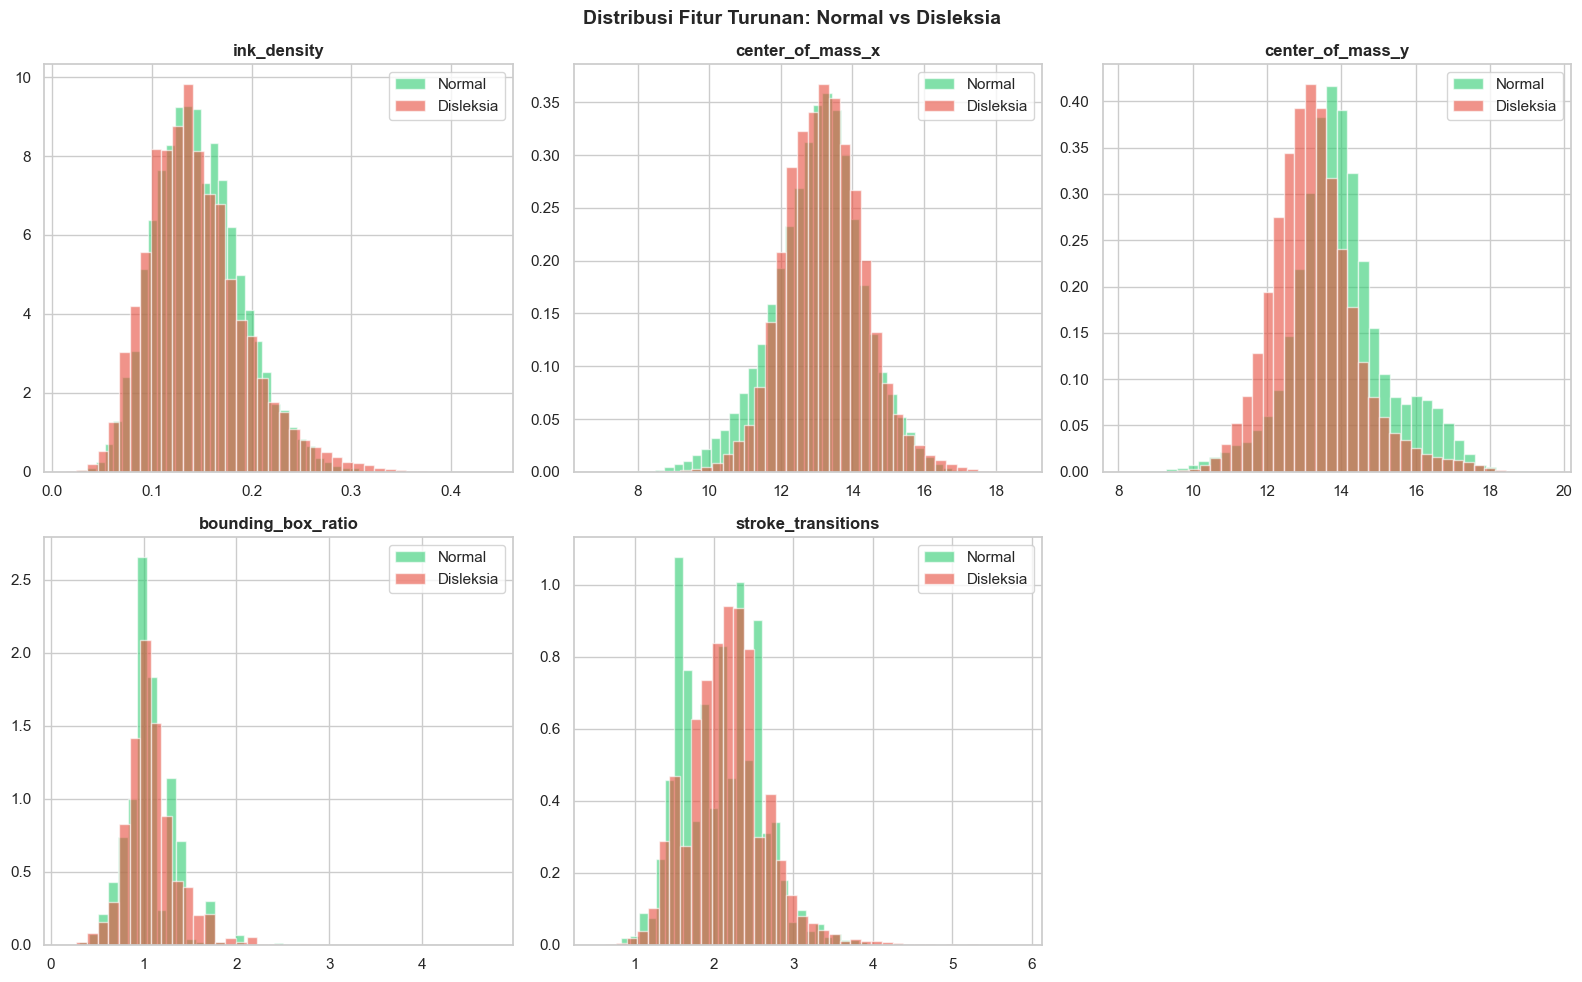

Grafik distribusi fitur tersimpan di assets/feature_engineering_distribution.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

feature_cols = ['ink_density', 'center_of_mass_x', 'center_of_mass_y', 
                'bounding_box_ratio', 'stroke_transitions']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Turunan: Normal vs Disleksia', fontsize=14, fontweight='bold')

for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 3][idx % 3]
    for label, color, name in [(0, '#2ECC71', 'Normal'), (1, '#E74C3C', 'Disleksia')]:
        subset = df_final[df_final['target_class'] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend()

# Kosongkan subplot ke-6 yang tidak terpakai
axes[1][2].axis('off')
plt.tight_layout()
plt.savefig('../assets/feature_engineering_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik distribusi fitur tersimpan di assets/feature_engineering_distribution.png')

In [6]:
# === Ringkasan Statistik per Kelas ===
print('=== Rata-rata Fitur per Kelas ===')
summary = df_final.groupby('target_class')[feature_cols].mean()
summary.index = ['Normal (0)', 'Disleksia (1)']
print(summary.round(4).to_string())

print('\n=== Selisih Absolut (Disleksia - Normal) ===')
diff = summary.loc['Disleksia (1)'] - summary.loc['Normal (0)']
print(diff.round(4).to_string())
print('\nFitur dengan selisih terbesar menunjukkan potensi diskriminatif tertinggi untuk model AI.')

=== Rata-rata Fitur per Kelas ===
               ink_density  center_of_mass_x  center_of_mass_y  bounding_box_ratio  stroke_transitions
Normal (0)          0.1474           13.0282           13.9595              1.0661              2.0851
Disleksia (1)       0.1449           13.2241           13.2719              1.0860              2.1599

=== Selisih Absolut (Disleksia - Normal) ===
ink_density          -0.0025
center_of_mass_x      0.1959
center_of_mass_y     -0.6876
bounding_box_ratio    0.0199
stroke_transitions    0.0747

Fitur dengan selisih terbesar menunjukkan potensi diskriminatif tertinggi untuk model AI.


### 7B. Simpan Dataset Final + Fitur Turunan

In [7]:
# === Simpan CSV dengan kolom fitur baru ===
df_final.to_csv(CSV_OUTPUT, index=False)
print(f'Dataset tersimpan: {CSV_OUTPUT}')
print(f'Kolom final: {df_final.columns.tolist()}')
print(f'Total baris: {len(df_final):,}')
print(f'\nData Dictionary Fitur Baru:')
print('  ink_density        : Kepadatan tinta (0.0-1.0). Semakin tinggi = semakin banyak coretan.')
print('  center_of_mass_x   : Titik tengah goresan sumbu-X (0-27). Menyimpang = asimetris.')
print('  center_of_mass_y   : Titik tengah goresan sumbu-Y (0-27).')
print('  bounding_box_ratio : Rasio tinggi/lebar bounding box goresan. <1 = melebar, >1 = memanjang.')
print('  stroke_transitions : Rata-rata transisi warna per baris. Tinggi = goresan berantakan.')

Dataset tersimpan: master_dataset_final_balanced_rill_featured.csv
Kolom final: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class', 'ink_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions']
Total baris: 160,425

Data Dictionary Fitur Baru:
  ink_density        : Kepadatan tinta (0.0-1.0). Semakin tinggi = semakin banyak coretan.
  center_of_mass_x   : Titik tengah goresan sumbu-X (0-27). Menyimpang = asimetris.
  center_of_mass_y   : Titik tengah goresan sumbu-Y (0-27).
  bounding_box_ratio : Rasio tinggi/lebar bounding box goresan. <1 = melebar, >1 = memanjang.
  stroke_transitions : Rata-rata transisi warna per baris. Tinggi = goresan berantakan.


---
## 📦 Kompresi Dataset
Kompilasi folder `Dataset/Gambo` menjadi `.zip` agar mudah dibagikan kepada kolega.

In [8]:
import shutil
import os

folder_to_zip = 'Dataset/Gambo_Balanced'
output_zip = 'Dataset_Gambo_putihkeHitam'

if os.path.exists(folder_to_zip):
    print(f"Mengompresi {folder_to_zip} menjadi {output_zip}.zip...")
    shutil.make_archive(output_zip, 'zip', folder_to_zip)
    print("✅ Selesai! File zip berhasil dibuat di direktori saat ini.")
else:
    print(f"❌ Folder {folder_to_zip} tidak ditemukan!")


Mengompresi Dataset/Gambo_Balanced menjadi Dataset_Gambo_putihkeHitam.zip...
✅ Selesai! File zip berhasil dibuat di direktori saat ini.


In [34]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# Target CSV
CSV_SRC = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\Dataset_Dyslexia_NoAugmentation.csv'
# Target Output
OUTPUT = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\dyslexialens_test_noAugmentation.csv.gz'
ROOT_DIR = r'd:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\notebooks\Scrap\'

df = pd.read_csv(CSV_SRC)
test_df = df[df['split'] == 'Test'].copy()
print(f'Test images to process: {len(test_df):,}')

rows = []
errors = 0
for i, (_, row) in enumerate(test_df.iterrows()):
    img_path = row['image_path']
    # Check if absolute path
    if not os.path.exists(img_path):
        img_path = os.path.join(ROOT_DIR, row['image_path'])
        
    if not os.path.exists(img_path):
        errors += 1
        continue

    try:
        img = Image.open(img_path).convert('L').resize((28, 28))
        pixels = np.array(img, dtype=np.uint8).flatten()
        pixel_row = [int(row['target_class'])] + pixels.tolist()
        rows.append(pixel_row)
    except Exception as e:
        errors += 1
        print(f"Error reading {img_path}: {e}")

    if (i + 1) % 5000 == 0:
        print(f'  Processed {i+1:,}/{len(test_df):,}...')

# Build DataFrame
print("Building dataframe...")
cols = ['label'] + [f'pixel{i}' for i in range(784)]
df_out = pd.DataFrame(rows, columns=cols)
df_out = df_out.astype(np.uint8)

# Save compressed
print("Compressing and saving to disk...")
df_out.to_csv(OUTPUT, index=False, compression='gzip')
size_mb = os.path.getsize(OUTPUT) / (1024 * 1024)
print(f'\nDone! {OUTPUT} ({size_mb:.1f} MB)')
print(f'Total images: {len(df_out):,} | Errors: {errors}')
print(df_out['label'].value_counts().rename({0:'Normal', 1:'Disleksia'}))

Test images to process: 23,468
  Processed 5,000/23,468...
  Processed 10,000/23,468...
  Processed 15,000/23,468...
  Processed 20,000/23,468...
Building dataframe...
Compressing and saving to disk...

Done! d:\Tugas\Kuliah\Semester 6\Dicoding\Capstone Project\Dataset Disleksia\csv_metadata\dyslexialens_test_noAugmentation.csv.gz (6.1 MB)
Total images: 23,468 | Errors: 0
label
Disleksia    18069
Normal        5399
Name: count, dtype: int64
